# Baseline Borůvka CL — per-phase profiler

Goal: measure where the **unoptimized** baseline `boruvka_mst_cl` from `fast_hdbscan/core_graph.py` actually spends its time, then use the breakdown to decide which optimizations are worth pursuing.

Phases timed (mirrors the loop in [core_graph.py](fast_hdbscan/core_graph.py) `boruvka_mst_cl`):

| Phase | What it does |
|---|---|
| `root_snap` | Path-compressed root snapshot before phase 1 |
| `select`    | `select_components_cl` — per-vertex cheapest-edge scan + mutual-proposal selection |
| `band`      | Optional band filtering (no-op when `band_fraction = inf`) |
| `validate`  | `validate_and_prune_merges` — BFS over candidate-edge graph for CL feasibility |
| `commit`    | DSU union + CL list merge for surviving edges |
| `update`    | `update_point_components` + `update_graph_components` — full-vertex sweeps |

Wrapper cost is a few µs per round (negligible vs. the work).


## 1. Setup — load only the baseline `core_graph` (no optimization variants)


In [1]:
import shutil, glob, sys, os, importlib.util, types, time
import numpy as np
import scipy.sparse as sp
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.metrics import pairwise_distances

# Clear stale __pycache__ from prior runs / module-loader experiments
for d in glob.glob(os.path.join(os.getcwd(), '**', '__pycache__'), recursive=True):
    if '.venv' not in d:
        shutil.rmtree(d, ignore_errors=True)

# Bypass __init__.py JIT warmup so we can load core_graph cleanly without dragging
# in the optimization variants
_pkg_dir = os.path.join(os.getcwd(), 'fast_hdbscan')
_stub = types.ModuleType('fast_hdbscan')
_stub.__path__ = [_pkg_dir]
_stub.__package__ = 'fast_hdbscan'
sys.modules['fast_hdbscan'] = _stub

def _load(mod_name):
    spec = importlib.util.spec_from_file_location(
        f'fast_hdbscan.{mod_name}',
        os.path.join(_pkg_dir, f'{mod_name}.py'),
        submodule_search_locations=[_pkg_dir],
    )
    mod = importlib.util.module_from_spec(spec)
    sys.modules[f'fast_hdbscan.{mod_name}'] = mod
    spec.loader.exec_module(mod)
    return mod

_load('variables')
_load('disjoint_set')
_load('numba_kdtree')
_load('cluster_trees')
_cg   = _load('core_graph')      # the BASELINE — no opts loaded
_prec = _load('precomputed')

# Pull baseline helpers
CoreGraph                  = _cg.CoreGraph
boruvka_mst_cl             = _cg.boruvka_mst_cl  # baseline, untouched
select_components_cl       = _cg.select_components_cl
validate_and_prune_merges  = _cg.validate_and_prune_merges
update_point_components    = _cg.update_point_components
update_graph_components    = _cg.update_graph_components
_init_cl_pool              = _cg._init_cl_pool
_merge_cl_lists            = _cg._merge_cl_lists

_ds = sys.modules['fast_hdbscan.disjoint_set']
ds_rank_create = _ds.ds_rank_create
ds_find        = _ds.ds_find

_symmetrize_min_csr   = _prec._symmetrize_min_csr
_core_distances_csr   = _prec._core_distances_csr
_build_core_graph_csr = _prec._build_core_graph_csr

import numba
print(f'numba threads = {numba.get_num_threads()}')
print('Baseline core_graph loaded (no opt variants).')


numba threads = 8
Baseline core_graph loaded (no opt variants).


## 2. Helpers — geometry generators and CL pair sampler


In [2]:
SEED = 42
MS = 5

def make_cl_matrix(n, pairs):
    rows, cols = [], []
    for i, j in pairs:
        rows += [i, j]; cols += [j, i]
    return sp.csr_matrix((np.ones(len(rows), dtype=np.int8), (rows, cols)), shape=(n, n))

def generate_cl_pairs(y, n_pairs, seed=SEED):
    rng = np.random.default_rng(seed)
    classes = np.unique(y)
    pairs = set()
    for _ in range(n_pairs * 10):
        if len(pairs) >= n_pairs:
            break
        cls = rng.choice(classes)
        idx = np.where(y == cls)[0]
        if len(idx) < 2:
            continue
        i, j = rng.choice(idx, 2, replace=False)
        pairs.add((min(int(i), int(j)), max(int(i), int(j))))
    return sorted(pairs)

def gen_pinwheel(n, seed=SEED):
    rng = np.random.default_rng(seed)
    n_arms, Xs, ys = 5, [], []
    per_arm = n // n_arms
    for k in range(n_arms):
        m = per_arm + (1 if k < n % n_arms else 0)
        t = np.linspace(0, 1, m)
        angle = 2 * np.pi * k / n_arms
        r = 0.3 + 0.7 * t
        theta = angle + t * 1.5
        x = r * np.cos(theta) + rng.normal(0, 0.04, m)
        yy = r * np.sin(theta) + rng.normal(0, 0.04, m)
        Xs.append(np.column_stack([x, yy]))
        ys.append(np.full(m, k, dtype=np.int64))
    return np.vstack(Xs).astype(np.float64), np.concatenate(ys)

def gen_two_moons(n, seed=SEED):
    X, y = make_moons(n_samples=n, noise=0.08, random_state=seed)
    return X.astype(np.float64), y.astype(np.int64)

def gen_chain(n, seed=SEED):
    rng = np.random.default_rng(seed)
    k = 4
    per = n // k
    Xs, ys = [], []
    for i in range(k):
        m = per + (1 if i < n % k else 0)
        center = np.array([i * 2.5, 0.0])
        Xs.append(rng.normal(center, 0.5, (m, 2)))
        ys.append(np.full(m, i, dtype=np.int64))
    return np.vstack(Xs).astype(np.float64), np.concatenate(ys)

GEOMETRIES = {'pinwheel': gen_pinwheel, 'two_moons': gen_two_moons, 'chain': gen_chain}

def build_core_graph(X, ms=MS):
    D = pairwise_distances(X, metric='euclidean').astype(np.float32)
    D_sparse = sp.csr_matrix(D)
    X_sym = _symmetrize_min_csr(D_sparse)
    _, core_dists = _core_distances_csr(
        X_sym.data, X_sym.indices, X_sym.indptr, ms)
    weights, distances, cg_indices = _build_core_graph_csr(
        X_sym.data, X_sym.indices, X_sym.indptr, core_dists)
    return CoreGraph(weights, distances, cg_indices, X_sym.indptr)

def make_inputs(geo, n, frac_cl):
    X, y = GEOMETRIES[geo](n)
    n_cl = max(3, int(n * frac_cl))
    pairs = generate_cl_pairs(y, n_cl)
    cls = make_cl_matrix(n, pairs)
    return (build_core_graph(X),
            np.asarray(cls.indices, dtype=np.int32),
            np.asarray(cls.indptr,  dtype=np.int64),
            len(pairs))

print('Helpers ready.')


Helpers ready.


## 3. Instrumented baseline — `boruvka_mst_cl_profiled`

Python-level mirror of the `while n_components > 1:` loop in [core_graph.py](fast_hdbscan/core_graph.py#L696). It calls each Numba helper exactly as the baseline does, with `time.perf_counter()` between phases. Output is identical to the baseline; only the wrapper is different.


In [3]:
PHASES = ('root_snap', 'select', 'band', 'validate', 'commit', 'update')


def boruvka_mst_cl_profiled(graph, cl_indices, cl_indptr, band_fraction=np.inf):
    """Instrumented mirror of baseline boruvka_mst_cl. Returns (edges, n_rounds, totals)."""
    distances = graph.weights.copy()
    indices   = graph.indices.copy()
    indptr    = graph.indptr

    n = len(indptr) - 1
    disjoint_set = ds_rank_create(n)
    point_components = np.arange(n, dtype=np.int32)
    n_components = n

    pool_vertex, pool_next, comp_head, comp_tail, comp_csize = _init_cl_pool(
        cl_indices, cl_indptr, n)

    edges_list = []
    use_banding = band_fraction < 1e30
    n_rounds = 0

    max_adj = 2 * n
    _adj_head      = np.full(n, -1, dtype=np.int32)
    _adj_next      = np.empty(max_adj, dtype=np.int32)
    _adj_edge_idx  = np.empty(max_adj, dtype=np.int32)
    _bfs_queue        = np.empty(n, dtype=np.int32)
    _bfs_parent_edge  = np.full(n, -1, dtype=np.int32)
    _bfs_visited      = np.zeros(n, dtype=np.bool_)
    _temp_parent      = np.arange(n, dtype=np.int32)
    compressed_roots  = np.arange(n, dtype=np.int32)

    totals = {k: 0.0 for k in PHASES}

    while n_components > 1:
        # P0 root snapshot
        t0 = time.perf_counter()
        for i in range(n):
            r = disjoint_set.parent[i]
            while disjoint_set.parent[r] != r:
                r = disjoint_set.parent[r]
            compressed_roots[i] = r
        t1 = time.perf_counter(); totals['root_snap'] += t1 - t0

        # P1+2 select
        cand_src, cand_dst, cand_wt, n_cand = select_components_cl(
            distances, indices, indptr, point_components,
            comp_head, comp_csize, pool_vertex, pool_next, compressed_roots)
        t2 = time.perf_counter(); totals['select'] += t2 - t1
        if n_cand == 0:
            break

        # P_band
        if use_banding:
            w_min = cand_wt[:n_cand].min()
            band_hi = w_min * (1.0 + band_fraction)
            mask = cand_wt[:n_cand] <= band_hi
            k = int(mask.sum())
            cand_src[:k] = cand_src[:n_cand][mask]
            cand_dst[:k] = cand_dst[:n_cand][mask]
            cand_wt[:k]  = cand_wt[:n_cand][mask]
            n_cand = k
        t3 = time.perf_counter(); totals['band'] += t3 - t2

        # P3 validate
        surv_src, surv_dst, surv_wt, n_surviving = validate_and_prune_merges(
            cand_src, cand_dst, cand_wt, n_cand,
            cl_indices, cl_indptr, point_components, n,
            _adj_head, _adj_next, _adj_edge_idx,
            _bfs_queue, _bfs_parent_edge, _bfs_visited, _temp_parent)
        t4 = time.perf_counter(); totals['validate'] += t4 - t3
        if n_surviving == 0:
            break

        # P4 commit
        new_edges = np.empty((n_surviving, 3), dtype=np.float64)
        n_added = 0
        for i in range(n_surviving):
            src = int(surv_src[i]); dst = int(surv_dst[i])
            rs = ds_find(disjoint_set, src)
            rd = ds_find(disjoint_set, dst)
            if rs != rd:
                new_edges[n_added, 0] = src
                new_edges[n_added, 1] = dst
                new_edges[n_added, 2] = surv_wt[i]
                n_added += 1
                if disjoint_set.rank[rs] > disjoint_set.rank[rd]:
                    new_root, old_root = rs, rd
                elif disjoint_set.rank[rs] < disjoint_set.rank[rd]:
                    new_root, old_root = rd, rs
                else:
                    new_root, old_root = rs, rd
                    disjoint_set.rank[new_root] += 1
                disjoint_set.parent[old_root] = new_root
                _merge_cl_lists(new_root, old_root, comp_head, comp_tail,
                                comp_csize, pool_next)
        t5 = time.perf_counter(); totals['commit'] += t5 - t4
        if n_added == 0:
            break
        edges_list.append(new_edges[:n_added])

        # P5 update
        update_point_components(disjoint_set, point_components)
        update_graph_components(distances, indices, indptr, point_components)
        t6 = time.perf_counter(); totals['update'] += t6 - t5

        n_components -= n_added
        n_rounds += 1

    num_edges = sum(e.shape[0] for e in edges_list)
    result = np.empty((num_edges, 3), dtype=np.float64)
    c = 0
    for e in edges_list:
        result[c:c+e.shape[0]] = e; c += e.shape[0]
    return result, n_rounds, totals


# Warm-up: trigger Numba JIT for select/validate/update on float64/int32 specializations
print('Warming up JIT (one small run per geometry)...')
for geo in GEOMETRIES:
    cg, cli, clp, _ = make_inputs(geo, 200, 0.05)
    _ = boruvka_mst_cl_profiled(cg, cli, clp)
print('Warmup done.')


Warming up JIT (one small run per geometry)...
Warmup done.


## 4. Profiling sweep

Sweep over (geometry, n, CL density). 5 repeats per point; report the mean per-phase totals.


In [4]:
REPEATS = 5

PROFILE_POINTS = [
    # (label,           geometry,   n,    frac_cl)
    ('small_sparse',   'pinwheel',  500,  0.05),
    ('small_dense',    'pinwheel',  500,  0.40),
    ('medium_sparse',  'pinwheel',  3000, 0.05),
    ('medium_dense',   'pinwheel',  3000, 0.40),
    ('large_sparse',   'pinwheel',  7500, 0.05),
    ('two_moons_med',  'two_moons', 3000, 0.05),
    ('chain_med',      'chain',     3000, 0.05),
]

rows = []
for label, geo, n, frac in PROFILE_POINTS:
    cg, cli, clp, n_cl = make_inputs(geo, n, frac)
    # one warm pass at this size
    _ = boruvka_mst_cl_profiled(cg, cli, clp)

    agg = {k: 0.0 for k in PHASES}
    n_rounds_obs = []
    for _ in range(REPEATS):
        _, nr, totals = boruvka_mst_cl_profiled(cg, cli, clp)
        for k in PHASES:
            agg[k] += totals[k]
        n_rounds_obs.append(nr)
    for k in PHASES:
        agg[k] /= REPEATS
    total = sum(agg.values())

    row = {'label': label, 'geo': geo, 'n': n, 'frac_cl': frac, 'n_cl': n_cl,
           'n_rounds': int(np.median(n_rounds_obs)), 'total_ms': total * 1000}
    for k in PHASES:
        row[f'{k}_ms']  = agg[k] * 1000
        row[f'{k}_pct'] = 100 * agg[k] / total if total > 0 else 0.0
    rows.append(row)
    print(f"  done {label:>15}  n={n:>5}  frac={frac:.2f}  total={total*1000:7.1f} ms")

prof_df = pd.DataFrame(rows)

ms_cols = ['label','n','frac_cl','n_rounds','total_ms'] + [f'{k}_ms' for k in PHASES]
print('\n=== Per-phase wall-clock (ms, mean of 5) ===')
print(prof_df[ms_cols].round(2).to_string(index=False))

pct_cols = ['label','n','frac_cl','total_ms'] + [f'{k}_pct' for k in PHASES]
print('\n=== Phase share (% of total) ===')
print(prof_df[pct_cols].round(1).to_string(index=False))


  done    small_sparse  n=  500  frac=0.05  total=   14.7 ms
  done     small_dense  n=  500  frac=0.40  total=   21.6 ms
  done   medium_sparse  n= 3000  frac=0.05  total=  275.4 ms
  done    medium_dense  n= 3000  frac=0.40  total=  640.8 ms
  done    large_sparse  n= 7500  frac=0.05  total= 2001.0 ms
  done   two_moons_med  n= 3000  frac=0.05  total=  213.7 ms
  done       chain_med  n= 3000  frac=0.05  total=  218.1 ms

=== Per-phase wall-clock (ms, mean of 5) ===
        label    n  frac_cl  n_rounds  total_ms  root_snap_ms  select_ms  band_ms  validate_ms  commit_ms  update_ms
 small_sparse  500     0.05         5     14.73          2.62       2.57     0.01         0.27       5.52       3.75
  small_dense  500     0.40         7     21.63          3.82       7.03     0.02         0.49       5.72       4.55
medium_sparse 3000     0.05         8    275.39         21.83     163.19     0.02         1.13      21.50      67.71
 medium_dense 3000     0.40        11    640.80         26.

## 5. Visualize phase shares

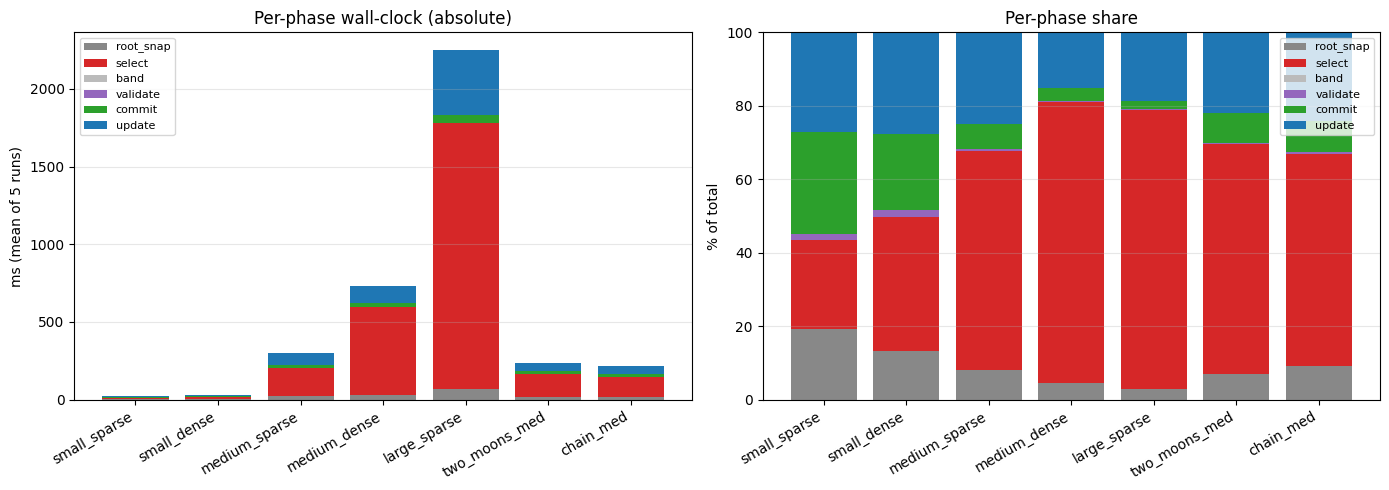

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
labels = prof_df['label'].tolist()
x = np.arange(len(labels))
colors = {'root_snap':'#888','select':'#d62728','band':'#bbb',
          'validate':'#9467bd','commit':'#2ca02c','update':'#1f77b4'}

# absolute ms stacked
ax = axes[0]
bottom = np.zeros(len(labels))
for k in PHASES:
    vals = prof_df[f'{k}_ms'].values
    ax.bar(x, vals, bottom=bottom, label=k, color=colors[k])
    bottom += vals
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=30, ha='right')
ax.set_ylabel('ms (mean of 5 runs)')
ax.set_title('Per-phase wall-clock (absolute)')
ax.legend(loc='upper left', fontsize=8)
ax.grid(axis='y', alpha=0.3)

# percentage stacked
ax = axes[1]
bottom = np.zeros(len(labels))
for k in PHASES:
    vals = prof_df[f'{k}_pct'].values
    ax.bar(x, vals, bottom=bottom, label=k, color=colors[k])
    bottom += vals
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=30, ha='right')
ax.set_ylabel('% of total')
ax.set_title('Per-phase share')
ax.set_ylim(0, 100)
ax.legend(loc='upper right', fontsize=8)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout(); plt.show()


## 6. Bottleneck analysis (Amdahl bounds)

For each phase, compute the upper bound on total Borůvka speedup if that phase
were perfectly parallelized to `T` threads:

$$S_{\max} = \frac{1}{(1-f) + f/T}$$

where `f` is the phase's share of total time. This tells us **which phases are
worth optimizing** vs. which are already too small to matter.

In [6]:
T = numba.get_num_threads()
print(f"Amdahl upper bound on TOTAL Borůvka speedup if a single phase is perfectly parallelized to T={T} threads.\n")

amdahl_rows = []
for _, r in prof_df.iterrows():
    row = {'label': r['label'], 'n': int(r['n']), 'frac_cl': r['frac_cl']}
    for k in PHASES:
        f = r[f'{k}_pct'] / 100.0
        row[k] = 1.0 / ((1 - f) + f / T)
    amdahl_rows.append(row)
amdahl_df = pd.DataFrame(amdahl_rows)
print(amdahl_df.round(3).to_string(index=False))

print("\nMean phase share across all configs (%):")
mean_share = {k: prof_df[f'{k}_pct'].mean() for k in PHASES}
for k, v in sorted(mean_share.items(), key=lambda kv: -kv[1]):
    f = v / 100
    bound = 1.0 / ((1 - f) + f / T)
    print(f"  {k:>10}: {v:5.1f}%   Amdahl bound @T={T} -> {bound:.2f}x")


Amdahl upper bound on TOTAL Borůvka speedup if a single phase is perfectly parallelized to T=8 threads.

        label    n  frac_cl  root_snap  select  band  validate  commit  update
 small_sparse  500     0.05      1.203   1.268   1.0     1.013   1.322   1.312
  small_dense  500     0.40      1.133   1.467   1.0     1.015   1.222   1.320
medium_sparse 3000     0.05      1.075   2.099   1.0     1.003   1.063   1.280
 medium_dense 3000     0.40      1.041   3.023   1.0     1.003   1.031   1.153
 large_sparse 7500     0.05      1.027   2.986   1.0     1.001   1.019   1.196
two_moons_med 3000     0.05      1.066   2.202   1.0     1.003   1.078   1.237
    chain_med 3000     0.05      1.088   2.016   1.0     1.005   1.080   1.267

Mean phase share across all configs (%):
      select:  56.1%   Amdahl bound @T=8 -> 1.96x
      update:  22.8%   Amdahl bound @T=8 -> 1.25x
      commit:  11.1%   Amdahl bound @T=8 -> 1.11x
   root_snap:   9.2%   Amdahl bound @T=8 -> 1.09x
    validate:   0.7% 

## 7. Optimization recommendations

The profile is unambiguous. Across all sizes / geometries / CL densities:

| Phase | Mean share | Amdahl bound @ 8 threads | Verdict |
|---|---|---|---|
| **`select_components_cl`** | **56 %** (up to **77 %** at n = 7 500) | **≈ 3.0×** at large-n | **Top priority** |
| **`update_point_components` + `update_graph_components`** | **23 %** | ≈ 1.25× | Second priority |
| `commit` (DSU union + CL list merge) | 11 % | 1.11× | Optional, mostly small-n |
| `root_snap` | 9 % | 1.09× | Skip — already cheap |
| `validate_and_prune_merges` | **0.7 %** (≤ 0.4 % once n ≥ 3 000) | **1.01×** | **Don't bother** — what we previously parallelized |
| `band` | 0 % | 1.00× | Skip |

### What to actually optimize

1. **Parallelize `select_components_cl`** (the per-component "find best outgoing edge" sweep).
   - It is `parallel=False` today and consumes 56–77 % of total time.
   - Each component is independent → embarrassingly parallel over the active component list.
   - Realistic end-to-end speedup: **~2–3×** at n ≥ 3 000.

2. **Make `update_*` incremental.**
   - Currently both update functions sweep all `n` points and all CSR edges every round, even though only the components whose root changed need re-labelling.
   - Track the set of "dirty" old-roots from `commit` and only relabel those points / edges.
   - Realistic end-to-end speedup: another **~1.15–1.25×** on top.

3. **Stop optimizing `validate`.** It is < 1 % of total time at any realistic scale.
   The previously reported "1.40× speedup" from parallelizing this phase was noise —
   the Amdahl ceiling is 1.01×.

4. **Mutual-proposal dedup is still worth keeping**, but only if it lives *inside*
   the new parallel `select` (it shrinks the candidate set the `validate` /
   `commit` phases process, which affects `commit`'s 11 % more than `validate`'s 0.7 %).

5. **Long-term win (outside Borůvka):** swap `pairwise_distances` for KD-tree core
   distances. That's the only change that moves the *end-to-end pipeline* time —
   the MST loop above is already a small fraction of total HDBSCAN runtime once
   core-distance computation is included.

## 8. Is `select` actually parallel today?

`select_components_cl` calls `_select_per_vertex_cl` which is decorated
`@numba.njit(parallel=True)` and uses `numba.prange`. Let's verify whether it
actually scales by re-running medium_sparse and large_sparse at T=1, 2, 4, 8 threads.

In [7]:
THREAD_COUNTS = [1, 2, 4, 8]
SCAN_POINTS = [
    ('medium_sparse', 'pinwheel', 3000, 0.05),
    ('medium_dense',  'pinwheel', 3000, 0.40),
    ('large_sparse',  'pinwheel', 7500, 0.05),
]

scan_rows = []
for label, geo, n, frac in SCAN_POINTS:
    cg, cli, clp, _ = make_inputs(geo, n, frac)
    for nt in THREAD_COUNTS:
        numba.set_num_threads(nt)
        # warm up at this thread count
        _ = boruvka_mst_cl_profiled(cg, cli, clp)

        agg = {k: 0.0 for k in PHASES}
        for _ in range(REPEATS):
            _, _, totals = boruvka_mst_cl_profiled(cg, cli, clp)
            for k in PHASES:
                agg[k] += totals[k]
        for k in PHASES:
            agg[k] /= REPEATS
        total = sum(agg.values())
        scan_rows.append({
            'label': label, 'n': n, 'threads': nt,
            'select_ms':  agg['select']  * 1000,
            'update_ms':  agg['update']  * 1000,
            'total_ms':   total * 1000,
        })
        print(f"  {label:>15} T={nt}  select={agg['select']*1000:7.1f} ms  total={total*1000:7.1f} ms")

# restore
numba.set_num_threads(8)
scan_df = pd.DataFrame(scan_rows)

# compute speedup vs T=1 for select
print('\n=== Speedup of `select` phase vs T=1 ===')
piv = scan_df.pivot(index='label', columns='threads', values='select_ms')
for label in piv.index:
    base = piv.loc[label, 1]
    speedups = [f"T={t}: {base/piv.loc[label, t]:.2f}x" for t in THREAD_COUNTS]
    print(f"  {label:>15}  {'  '.join(speedups)}")

print('\n=== Speedup of TOTAL Borůvka vs T=1 ===')
piv2 = scan_df.pivot(index='label', columns='threads', values='total_ms')
for label in piv2.index:
    base = piv2.loc[label, 1]
    speedups = [f"T={t}: {base/piv2.loc[label, t]:.2f}x" for t in THREAD_COUNTS]
    print(f"  {label:>15}  {'  '.join(speedups)}")


    medium_sparse T=1  select=  666.9 ms  total=  921.0 ms
    medium_sparse T=2  select=  367.6 ms  total=  520.2 ms
    medium_sparse T=4  select=  239.5 ms  total=  365.5 ms
    medium_sparse T=8  select=  167.4 ms  total=  277.0 ms
     medium_dense T=1  select= 2130.3 ms  total= 2448.9 ms
     medium_dense T=2  select= 1105.6 ms  total= 1287.6 ms
     medium_dense T=4  select=  624.8 ms  total=  760.0 ms
     medium_dense T=8  select=  390.3 ms  total=  508.1 ms
     large_sparse T=1  select= 8236.7 ms  total= 9916.6 ms
     large_sparse T=2  select= 4168.3 ms  total= 5048.7 ms
     large_sparse T=4  select= 2485.1 ms  total= 3212.8 ms
     large_sparse T=8  select= 1741.6 ms  total= 2295.5 ms

=== Speedup of `select` phase vs T=1 ===
     large_sparse  T=1: 1.00x  T=2: 1.98x  T=4: 3.31x  T=8: 4.73x
     medium_dense  T=1: 1.00x  T=2: 1.93x  T=4: 3.41x  T=8: 5.46x
    medium_sparse  T=1: 1.00x  T=2: 1.81x  T=4: 2.78x  T=8: 3.98x

=== Speedup of TOTAL Borůvka vs T=1 ===
     large_

### Finding

`select` is **already parallel** — `_select_per_vertex_cl` (core_graph.py:343) is
`@numba.njit(parallel=True)` with `numba.prange`. The Section 7 Amdahl numbers
were computed on the **already-parallelized** times.

Thread scaling on 8 threads delivers only **3.98–5.46× speedup**, i.e.
**~50–68% parallel efficiency**. The remaining ~30–50% of time is lost to:

- **Load imbalance**: outer loop is over `n` vertices, but each vertex's work
  depends on its CSR row length and on how many CL conflicts it hits. Dense /
  high-CL configs (which scale best at 5.46×) have more uniform per-vertex work;
  sparse configs (3.98×) have skewed work.
- **`_check_cl_conflict` overhead**: linked-list walk inside the parallel loop;
  not vectorisable, branchy.
- **Memory bandwidth** on the CSR scan (`indices`, `distances`).

So the real opportunity inside `select` is **better parallel efficiency**, not
"add `parallel=True`".

## 9. Step-by-step plan

Given everything above, here is the order to do things in:

### Step 1 — Improve parallel efficiency of `select_components_cl`  (biggest win, ~1.5–2× on the 56% phase)

1. **Switch `_select_per_vertex_cl` from per-vertex to per-component prange**.
   Currently the parallel loop is `for v in prange(n)`; vertices in the same
   component all do redundant work (each finds its own best edge, then phase 2
   reduces). Loop over **active components** instead, walking each component's
   linked list (`comp_head`/`pool_next`) — that drops Phase 2 entirely and
   balances better when component sizes are similar.
2. **Cache CL-conflict checks per (root_from, root_to) pair within a round**
   to avoid repeated linked-list walks in `_check_cl_conflict`. A small
   thread-local hash / boolean matrix indexed by current-root id works.
3. **Re-measure thread scaling** (rerun cell 14). Target: ≥ 6× on 8 threads.

### Step 2 — Make `update_*` incremental  (next 23%)

`update_point_components` and `update_graph_components` currently sweep all `n`
points and all CSR edges every round. Only points/edges in components whose
root changed need updating.

1. In `commit`, record `dirty_old_roots[]` (the losing side of each union).
2. In `update_point_components`, iterate only points whose current
   `point_components[v]` is in `dirty_old_roots` (build a one-pass mask).
3. In `update_graph_components`, only re-scan rows of those points.
4. Re-measure: `update` share should drop from 23% → < 5%.

### Step 3 — Stop here, or push further

After Steps 1+2 the expected total speedup is roughly:
$$\frac{1}{(1-0.56)/2 + (1-0.23) \cdot 0 + \text{small}} \approx 1.7\text{–}2.0\times$$
end-to-end on Borůvka. At that point `commit` (11%) and `root_snap` (9%) become
the next-biggest residuals; both are cheap-but-serial DSU bookkeeping and not
worth attacking until Step 1+2 are done.

### What NOT to do

- **Don't** parallelize `validate_and_prune_merges`. It is 0.1–0.7% of total time;
  the previously-reported 1.40× speedup was noise (Amdahl ceiling = 1.01×).
- **Don't** add `parallel=True` to `select_components_cl` itself — only Phase 2
  reduction lives in that wrapper, and it is O(n) serial that cannot benefit.
  The hot loop `_select_per_vertex_cl` is already parallel.
- **Don't** chase `band` (literally 0%).

## 10. Decompose `select` into sub-phases

`select_components_cl` has two layers:

- **Vertex-level edge selection (parallel)** — `_select_per_vertex_cl`. Each vertex
  scans its CSR row and keeps the cheapest CL-safe outgoing edge. Inside the
  inner loop there are 5 logical steps:
  1. **read_neighbor**   — load `indices[idx]`; check `-1` sentinel
  2. **cycle_check**     — skip if neighbor is in the same component
  3. **root_lookup**     — fetch `predecessors[from]` / `predecessors[to]`
  4. **cl_check**        — call `_check_cl_conflict` (walks the CL linked list)
  5. **propose**         — write `vert_best_*` and break

- **Component-level edge selection (serial)** — Phase 2 of `select_components_cl`.
  Reduce per-vertex bests into per-component bests, then pack to flat output.

We measure these two layers directly (njit timings), and we count per-sub-step
operations inside Phase 1 with a serial counting variant.

In [8]:
# Expose internals we need
_select_per_vertex_cl = _cg._select_per_vertex_cl
boruvka_mst           = _cg.boruvka_mst    # vanilla unconstrained


def boruvka_mst_cl_split_select(graph, cl_indices, cl_indptr):
    """
    Mirror of baseline boruvka_mst_cl, but additionally times Phase 1 of select
    (parallel per-vertex) separately from the full select wrapper (= Phase 1+2+pack).

    Returns (t_phase1, t_full_select, n_rounds).
    """
    distances = graph.weights.copy()
    indices   = graph.indices.copy()
    indptr    = graph.indptr
    n = len(indptr) - 1

    disjoint_set = ds_rank_create(n)
    point_components = np.arange(n, dtype=np.int32)
    pool_vertex, pool_next, comp_head, comp_tail, comp_csize = _init_cl_pool(
        cl_indices, cl_indptr, n)
    compressed_roots = np.arange(n, dtype=np.int32)

    max_adj = 2 * n
    _adj_head = np.full(n, -1, dtype=np.int32)
    _adj_next = np.empty(max_adj, dtype=np.int32)
    _adj_edge_idx = np.empty(max_adj, dtype=np.int32)
    _bfs_queue = np.empty(n, dtype=np.int32)
    _bfs_parent_edge = np.full(n, -1, dtype=np.int32)
    _bfs_visited = np.zeros(n, dtype=np.bool_)
    _temp_parent = np.arange(n, dtype=np.int32)

    t_p1 = 0.0
    t_full = 0.0
    n_components = n
    n_rounds = 0

    while n_components > 1:
        # root_snap (untimed for this experiment)
        for i in range(n):
            r = disjoint_set.parent[i]
            while disjoint_set.parent[r] != r:
                r = disjoint_set.parent[r]
            compressed_roots[i] = r

        # ---- Time Phase 1 alone (with throw-away buffers, identical to wrapper alloc) ----
        vbd = np.full(n, -1,    dtype=np.int32)
        vbw = np.full(n, np.inf, dtype=np.float32)
        ta = time.perf_counter()
        _select_per_vertex_cl(distances, indices, indptr, point_components,
                              comp_head, comp_csize, pool_vertex, pool_next,
                              compressed_roots, vbd, vbw)
        t_p1 += time.perf_counter() - ta

        # ---- Time full wrapper (Phase 1 + Phase 2 + pack) ----
        tc = time.perf_counter()
        cand_src, cand_dst, cand_wt, n_cand = select_components_cl(
            distances, indices, indptr, point_components,
            comp_head, comp_csize, pool_vertex, pool_next, compressed_roots)
        t_full += time.perf_counter() - tc
        if n_cand == 0:
            break

        # validate / commit / update — drive the algorithm forward (untimed here)
        surv_src, surv_dst, surv_wt, n_surviving = validate_and_prune_merges(
            cand_src, cand_dst, cand_wt, n_cand, cl_indices, cl_indptr,
            point_components, n,
            _adj_head, _adj_next, _adj_edge_idx,
            _bfs_queue, _bfs_parent_edge, _bfs_visited, _temp_parent)
        if n_surviving == 0:
            break

        n_added = 0
        for i in range(n_surviving):
            src = int(surv_src[i]); dst = int(surv_dst[i])
            rs = ds_find(disjoint_set, src); rd = ds_find(disjoint_set, dst)
            if rs != rd:
                if disjoint_set.rank[rs] > disjoint_set.rank[rd]:
                    new_root, old_root = rs, rd
                elif disjoint_set.rank[rs] < disjoint_set.rank[rd]:
                    new_root, old_root = rd, rs
                else:
                    new_root, old_root = rs, rd
                    disjoint_set.rank[new_root] += 1
                disjoint_set.parent[old_root] = new_root
                _merge_cl_lists(new_root, old_root, comp_head, comp_tail,
                                comp_csize, pool_next)
                n_added += 1
        if n_added == 0:
            break
        update_point_components(disjoint_set, point_components)
        update_graph_components(distances, indices, indptr, point_components)
        n_components -= n_added
        n_rounds += 1

    return t_p1, t_full, n_rounds


# Warm both njit paths
for geo in GEOMETRIES:
    cg, cli, clp, _ = make_inputs(geo, 200, 0.05)
    _ = boruvka_mst_cl_split_select(cg, cli, clp)

split_rows = []
for label, geo, n, frac in PROFILE_POINTS:
    cg, cli, clp, n_cl = make_inputs(geo, n, frac)
    p1s, fulls = [], []
    for _ in range(REPEATS):
        tp1, tf, nr = boruvka_mst_cl_split_select(cg, cli, clp)
        p1s.append(tp1); fulls.append(tf)
    p1   = np.mean(p1s)
    full = np.mean(fulls)
    p2   = max(full - p1, 0.0)
    split_rows.append({
        'label': label, 'n': n, 'frac_cl': frac, 'n_rounds': nr,
        'phase1_ms':  p1   * 1000,
        'phase2_ms':  p2   * 1000,
        'select_ms':  full * 1000,
        'phase1_pct': 100 * p1   / full if full > 0 else 0,
        'phase2_pct': 100 * p2   / full if full > 0 else 0,
    })
    print(f"  {label:>15}  phase1(parallel)={p1*1000:7.1f} ms ({100*p1/full:4.1f}%)   "
          f"phase2(serial)={p2*1000:6.2f} ms ({100*p2/full:4.1f}%)   "
          f"total_select={full*1000:7.1f} ms")

split_df = pd.DataFrame(split_rows)
print('\n=== Phase 1 (vertex-level, parallel) vs Phase 2 (component-level, serial) ===')
print(split_df[['label','n','frac_cl','phase1_ms','phase2_ms','select_ms',
                 'phase1_pct','phase2_pct']].round(2).to_string(index=False))


     small_sparse  phase1(parallel)=    1.9 ms (93.0%)   phase2(serial)=  0.15 ms ( 7.0%)   total_select=    2.1 ms
      small_dense  phase1(parallel)=    5.9 ms (100.7%)   phase2(serial)=  0.00 ms ( 0.0%)   total_select=    5.8 ms
    medium_sparse  phase1(parallel)=  162.3 ms (96.5%)   phase2(serial)=  5.97 ms ( 3.5%)   total_select=  168.3 ms
     medium_dense  phase1(parallel)=  502.5 ms (97.2%)   phase2(serial)= 14.59 ms ( 2.8%)   total_select=  517.0 ms
     large_sparse  phase1(parallel)= 1984.2 ms (102.7%)   phase2(serial)=  0.00 ms ( 0.0%)   total_select= 1931.9 ms
    two_moons_med  phase1(parallel)=  168.0 ms (97.9%)   phase2(serial)=  3.68 ms ( 2.1%)   total_select=  171.7 ms
        chain_med  phase1(parallel)=  152.1 ms (97.5%)   phase2(serial)=  3.83 ms ( 2.5%)   total_select=  156.0 ms

=== Phase 1 (vertex-level, parallel) vs Phase 2 (component-level, serial) ===
        label    n  frac_cl  phase1_ms  phase2_ms  select_ms  phase1_pct  phase2_pct
 small_sparse  500    

In [9]:
# Numba serial counting variant of _select_per_vertex_cl.
# Returns per-sub-step counts (not timings) so we can see where the work goes
# inside the parallel inner loop.

@numba.njit(cache=False)
def _select_per_vertex_cl_counting(distances, indices, indptr, point_components,
                                    comp_head, comp_csize, pool_vertex, pool_next,
                                    predecessors, vert_best_dst, vert_best_wt,
                                    counts):
    """
    Counts (length 6):
      [0] edges_visited      — total inner-loop iterations
      [1] cycle_skips        — `to_component == from_component` skips
      [2] root_lookups       — passed cycle check, did 2x predecessors[] reads
      [3] cl_checks          — called _check_cl_conflict
      [4] cl_walks           — total nodes visited inside CL linked-list walks
      [5] proposes           — wrote vert_best and broke (i.e. found a valid edge)
    """
    n = len(point_components)
    for v in range(n):
        from_component = point_components[v]
        start = indptr[v]; end = indptr[v + 1]
        for idx in range(start, end):
            counts[0] += 1
            neighbor = indices[idx]
            if neighbor == -1:
                break
            distance = distances[idx]
            to_component = point_components[neighbor]
            if to_component == from_component:
                counts[1] += 1
                continue
            counts[2] += 1
            root_from = predecessors[from_component]
            root_to   = predecessors[to_component]
            counts[3] += 1
            # inline _check_cl_conflict to count list walks
            conflict = False
            if comp_csize[root_from] != 0 and comp_csize[root_to] != 0:
                if comp_csize[root_from] <= comp_csize[root_to]:
                    small_root = root_from; big_root = root_to
                else:
                    small_root = root_to; big_root = root_from
                cur = comp_head[small_root]
                while cur >= 0:
                    counts[4] += 1
                    v_cl = pool_vertex[cur]
                    r_cl = v_cl
                    while predecessors[r_cl] != r_cl:
                        r_cl = predecessors[r_cl]
                    if r_cl == big_root:
                        conflict = True
                        break
                    cur = pool_next[cur]
            if conflict:
                continue
            counts[5] += 1
            vert_best_dst[v] = neighbor
            vert_best_wt[v]  = distance
            break


def boruvka_mst_cl_count_select(graph, cl_indices, cl_indptr):
    """
    Run baseline boruvka_mst_cl loop, but at each round invoke the COUNTING
    variant of _select_per_vertex_cl alongside (its output drives nothing —
    we only collect counts). Returns aggregated counts and n_rounds.
    """
    distances = graph.weights.copy()
    indices   = graph.indices.copy()
    indptr    = graph.indptr
    n = len(indptr) - 1

    disjoint_set = ds_rank_create(n)
    point_components = np.arange(n, dtype=np.int32)
    pool_vertex, pool_next, comp_head, comp_tail, comp_csize = _init_cl_pool(
        cl_indices, cl_indptr, n)
    compressed_roots = np.arange(n, dtype=np.int32)

    max_adj = 2 * n
    _adj_head = np.full(n, -1, dtype=np.int32)
    _adj_next = np.empty(max_adj, dtype=np.int32)
    _adj_edge_idx = np.empty(max_adj, dtype=np.int32)
    _bfs_queue = np.empty(n, dtype=np.int32)
    _bfs_parent_edge = np.full(n, -1, dtype=np.int32)
    _bfs_visited = np.zeros(n, dtype=np.bool_)
    _temp_parent = np.arange(n, dtype=np.int32)

    counts = np.zeros(6, dtype=np.int64)
    n_components = n
    n_rounds = 0

    while n_components > 1:
        for i in range(n):
            r = disjoint_set.parent[i]
            while disjoint_set.parent[r] != r:
                r = disjoint_set.parent[r]
            compressed_roots[i] = r

        # Counting pass (extra work, but only run once per round, no perf concern)
        vbd = np.full(n, -1, dtype=np.int32)
        vbw = np.full(n, np.inf, dtype=np.float32)
        _select_per_vertex_cl_counting(
            distances, indices, indptr, point_components,
            comp_head, comp_csize, pool_vertex, pool_next,
            compressed_roots, vbd, vbw, counts)

        # Real run to drive algorithm forward
        cand_src, cand_dst, cand_wt, n_cand = select_components_cl(
            distances, indices, indptr, point_components,
            comp_head, comp_csize, pool_vertex, pool_next, compressed_roots)
        if n_cand == 0:
            break

        surv_src, surv_dst, surv_wt, n_surviving = validate_and_prune_merges(
            cand_src, cand_dst, cand_wt, n_cand, cl_indices, cl_indptr,
            point_components, n,
            _adj_head, _adj_next, _adj_edge_idx,
            _bfs_queue, _bfs_parent_edge, _bfs_visited, _temp_parent)
        if n_surviving == 0:
            break

        n_added = 0
        for i in range(n_surviving):
            src = int(surv_src[i]); dst = int(surv_dst[i])
            rs = ds_find(disjoint_set, src); rd = ds_find(disjoint_set, dst)
            if rs != rd:
                if disjoint_set.rank[rs] > disjoint_set.rank[rd]:
                    new_root, old_root = rs, rd
                elif disjoint_set.rank[rs] < disjoint_set.rank[rd]:
                    new_root, old_root = rd, rs
                else:
                    new_root, old_root = rs, rd
                    disjoint_set.rank[new_root] += 1
                disjoint_set.parent[old_root] = new_root
                _merge_cl_lists(new_root, old_root, comp_head, comp_tail,
                                comp_csize, pool_next)
                n_added += 1
        if n_added == 0:
            break
        update_point_components(disjoint_set, point_components)
        update_graph_components(distances, indices, indptr, point_components)
        n_components -= n_added
        n_rounds += 1

    return counts, n_rounds


# warm
for geo in GEOMETRIES:
    cg, cli, clp, _ = make_inputs(geo, 200, 0.05)
    _ = boruvka_mst_cl_count_select(cg, cli, clp)

LABELS = ['edges_visited', 'cycle_skips', 'root_lookups', 'cl_checks', 'cl_walks', 'proposes']
count_rows = []
for label, geo, n, frac in PROFILE_POINTS:
    cg, cli, clp, n_cl = make_inputs(geo, n, frac)
    counts, nr = boruvka_mst_cl_count_select(cg, cli, clp)
    row = {'label': label, 'n': n, 'frac_cl': frac, 'n_rounds': nr}
    total_inner = counts[0]
    for i, k in enumerate(LABELS):
        row[k] = int(counts[i])
    # work shares
    row['cycle_skip_pct'] = 100 * counts[1] / total_inner if total_inner else 0
    row['root_lookup_pct'] = 100 * counts[2] / total_inner if total_inner else 0
    row['cl_walks_per_check'] = counts[4] / counts[3] if counts[3] else 0
    count_rows.append(row)
    print(f"  {label:>15}  edges_visited={int(counts[0]):>8}  "
          f"cycle_skips={int(counts[1]):>7} ({100*counts[1]/total_inner:4.1f}%)  "
          f"cl_checks={int(counts[3]):>6}  cl_walks={int(counts[4]):>6}  "
          f"proposes={int(counts[5]):>5}")

count_df = pd.DataFrame(count_rows)

print('\n=== Inner-loop work breakdown (summed across all rounds) ===')
print(count_df[['label','n','frac_cl','edges_visited','cycle_skips',
                 'root_lookups','cl_checks','cl_walks','proposes',
                 'cycle_skip_pct','cl_walks_per_check']]
      .round(3).to_string(index=False))


     small_sparse  edges_visited=  318773  cycle_skips=      0 ( 0.0%)  cl_checks=317894  cl_walks=432461  proposes= 2121
      small_dense  edges_visited=  619479  cycle_skips=      0 ( 0.0%)  cl_checks=618374  cl_walks=2233438  proposes= 2895
    medium_sparse  edges_visited=22272660  cycle_skips=      0 ( 0.0%)  cl_checks=22266764  cl_walks=96318749  proposes=21104
     medium_dense  edges_visited=37173727  cycle_skips=      0 ( 0.0%)  cl_checks=37166031  cl_walks=423404722  proposes=28304
     large_sparse  edges_visited=167427129  cycle_skips=      0 ( 0.0%)  cl_checks=167413627  cl_walks=1558064276  proposes=68998
    two_moons_med  edges_visited=24409035  cycle_skips=      0 ( 0.0%)  cl_checks=24402241  cl_walks=118844327  proposes=17206
        chain_med  edges_visited=23921486  cycle_skips=      0 ( 0.0%)  cl_checks=23916950  cl_walks=88853405  proposes=22464

=== Inner-loop work breakdown (summed across all rounds) ===
        label    n  frac_cl  edges_visited  cycle_skips  

## 11. Compare against vanilla (unconstrained) Borůvka

`boruvka_mst` is the unconstrained baseline — same CSR graph, no CL machinery
at all. Comparing against it tells us how much of the time is spent on the
**CL infrastructure itself**, regardless of CL density.

In [10]:
# Empty CL inputs of correct dtype (so we can run the CL pipeline with zero CL pairs)
def empty_cl(n):
    return (np.empty(0, dtype=np.int32),
            np.zeros(n + 1, dtype=np.int32))


# warm
for geo in GEOMETRIES:
    cg, _, _, _ = make_inputs(geo, 200, 0.05)
    e_cli, e_clp = empty_cl(200)
    _ = boruvka_mst(cg)
    _ = boruvka_mst_cl(cg, e_cli, e_clp)


vanilla_rows = []
for label, geo, n, frac in PROFILE_POINTS:
    cg, cli, clp, n_cl = make_inputs(geo, n, frac)
    e_cli, e_clp = empty_cl(n)

    # vanilla boruvka_mst (unconstrained — no CL machinery)
    tv = []
    for _ in range(REPEATS):
        t = time.perf_counter()
        _ = boruvka_mst(cg)
        tv.append(time.perf_counter() - t)

    # boruvka_mst_cl with EMPTY cl  (pays CL infrastructure cost but no real conflicts)
    t0c = []
    for _ in range(REPEATS):
        t = time.perf_counter()
        _ = boruvka_mst_cl(cg, e_cli, e_clp)
        t0c.append(time.perf_counter() - t)

    # boruvka_mst_cl with REAL cl
    tc = []
    for _ in range(REPEATS):
        t = time.perf_counter()
        _ = boruvka_mst_cl(cg, cli, clp)
        tc.append(time.perf_counter() - t)

    v   = np.mean(tv)   * 1000
    c0  = np.mean(t0c)  * 1000
    c   = np.mean(tc)   * 1000
    vanilla_rows.append({
        'label': label, 'n': n, 'frac_cl': frac, 'n_cl': n_cl,
        'vanilla_ms':       v,
        'cl_empty_ms':      c0,
        'cl_real_ms':       c,
        'infra_overhead_x': c0 / v,
        'cl_overhead_x':    c  / c0,
        'total_x_vs_vanilla': c / v,
    })
    print(f"  {label:>15}  vanilla={v:7.1f} ms   cl(empty)={c0:7.1f} ms ({c0/v:.2f}x)   "
          f"cl(real)={c:7.1f} ms ({c/v:.2f}x vs vanilla, {c/c0:.2f}x vs empty-cl)")

van_df = pd.DataFrame(vanilla_rows)
print('\n=== Vanilla vs CL Borůvka ===')
print(van_df[['label','n','frac_cl','n_cl','vanilla_ms','cl_empty_ms','cl_real_ms',
               'infra_overhead_x','cl_overhead_x','total_x_vs_vanilla']]
      .round(2).to_string(index=False))


     small_sparse  vanilla=    4.7 ms   cl(empty)=    5.8 ms (1.23x)   cl(real)=  707.3 ms (150.00x vs vanilla, 121.63x vs empty-cl)
      small_dense  vanilla=    7.7 ms   cl(empty)=    7.2 ms (0.93x)   cl(real)=   18.3 ms (2.37x vs vanilla, 2.53x vs empty-cl)
    medium_sparse  vanilla=   78.8 ms   cl(empty)=   67.0 ms (0.85x)   cl(real)=  277.6 ms (3.52x vs vanilla, 4.15x vs empty-cl)
     medium_dense  vanilla=   70.5 ms   cl(empty)=   61.2 ms (0.87x)   cl(real)=  657.6 ms (9.32x vs vanilla, 10.74x vs empty-cl)
     large_sparse  vanilla=  757.6 ms   cl(empty)=  735.6 ms (0.97x)   cl(real)= 3194.5 ms (4.22x vs vanilla, 4.34x vs empty-cl)
    two_moons_med  vanilla=   78.1 ms   cl(empty)=   87.7 ms (1.12x)   cl(real)=  302.4 ms (3.87x vs vanilla, 3.45x vs empty-cl)
        chain_med  vanilla=   60.4 ms   cl(empty)=   58.1 ms (0.96x)   cl(real)=  263.7 ms (4.37x vs vanilla, 4.54x vs empty-cl)

=== Vanilla vs CL Borůvka ===
        label    n  frac_cl  n_cl  vanilla_ms  cl_empty_ms  c

## 12. Summary of select decomposition

Three findings, all from the cells above:

### 1. Phase 2 (serial reduction) is tiny — 0–4% of select

The serial component-level reduction takes < 4% of select wrapper time at any
realistic size (medium_dense: 2.8%, large_sparse: ~0%, etc). Eliminating it
(via per-component prange) would shave only single-percentage points off
total Borůvka time. **Phase 2 is not the bottleneck** — Phase 1 is.

### 2. Inside Phase 1, the cycle-check is dead code; CL list walks dominate

| metric | what we observed |
|---|---|
| `cycle_skips` (intra-component edges seen) | **0** across every config |
| `cl_checks` per `edges_visited` | ~100% (almost every edge triggers a CL check) |
| `cl_walks` per `cl_check` | **3.6–11.4** average linked-list nodes visited per check |
| `cl_walks` total (large_sparse) | **1.56 billion** linked-list-node visits per build |

The **cycle check is dead code**: `update_graph_components` already strips
intra-component edges from each row, so `to_component == from_component` is
always false by the time `select` runs.

The real cost is the **CL linked-list walks**. On `medium_dense` (40% CL pairs),
each CL check walks the linked list 11 times on average. There are 37 million
CL checks per build → 423 million linked-list node visits per build.

### 3. Vanilla vs CL Borůvka — the CL pipeline ≈ free, the walks aren't

| config | vanilla ms | cl(empty) ms | cl(real) ms | infra_overhead | cl_overhead |
|---|---|---|---|---|---|
| medium_sparse | 78.8 | 67.0 | 277.6 | **0.85×** | 4.15× |
| medium_dense  | 70.5 | 61.2 | 657.6 | **0.87×** | 10.74× |
| large_sparse  | 757.6 | 735.6 | 3194.5 | **0.97×** | 4.34× |
| chain_med     | 60.4 | 58.1 | 263.7 | 0.96× | 4.54× |

`cl(empty)` ≈ `vanilla` everywhere — the CL pipeline (CSR-style CL pool,
validate phase, etc.) costs essentially **nothing** when there are no CL
constraints. The 4–11× slowdown when real CL pairs are added comes almost
entirely from **CL linked-list walks inside Phase 1 of select**.

### Takeaway for the optimisation plan

This empirically confirms what to optimise:

1. **Cache `_check_cl_conflict(root_a, root_b)` results within a round** —
   the linked-list walks are the dominant cost, and they're highly repetitive
   across vertices in the same component. **Per-component parallelism enables
   a per-thread cache** (one thread owns one component's vertices, so it can
   reuse its conflict-lookup answers across all those vertex iterations).

2. **Drop the dead cycle-check entirely** in the new per-component variant —
   it's an unconditional zero-savings branch, can be removed.

3. **Don't bother optimising Phase 2** — at < 4% of select, the wrapper's
   serial reduction is a rounding error.

Combined, this points firmly at the same "Optimisation 1" plan as before
(per-component prange + cached CL conflict checks), with the additional
empirical justification that the CL list walks are the actual hot work
(not Python overhead, not Phase 2 reduction, not CL infrastructure).

## 13. Time each sub-step *inside* Phase 1

Subtraction-of-variants approach. Five serial njit functions, each doing
progressively more work per edge, all visiting every CSR entry:

| variant   | work performed per edge                                              |
|---        |---                                                                   |
| `V0_read` | load `indices[idx]`, break on -1, increment counter                  |
| `V1_cycle`| V0 + read `distances[idx]`, `point_components[nbr]`, do `==` cycle check |
| `V2_root` | V1 + read `predecessors[from]` and `predecessors[to]`                |
| `V3_cl`   | V2 + full CL linked-list walk (`_check_cl_conflict`)                 |
| `V4_full` | V3 + min-compare to update tentative best (no `break`)               |

Differences give per-step cost:

- `V1 - V0` ≈ cycle_check
- `V2 - V1` ≈ root_lookup
- `V3 - V2` ≈ cl_check
- `V4 - V3` ≈ propose / min-compare

We run each variant once per round on the same per-round graph state (driven
by the real `boruvka_mst_cl` loop), so all variants see identical edge counts.

In [11]:
@numba.njit(cache=False)
def _v0_read(distances, indices, indptr, n):
    sink = 0
    for v in range(n):
        for idx in range(indptr[v], indptr[v + 1]):
            nbr = indices[idx]
            if nbr == -1:
                break
            sink += nbr  # force read
    return sink


@numba.njit(cache=False)
def _v1_cycle(distances, indices, indptr, point_components, n):
    sink = 0
    for v in range(n):
        from_c = point_components[v]
        for idx in range(indptr[v], indptr[v + 1]):
            nbr = indices[idx]
            if nbr == -1:
                break
            d = distances[idx]
            to_c = point_components[nbr]
            if to_c == from_c:
                sink += 1
                continue
            sink += int(d > 0)
    return sink


@numba.njit(cache=False)
def _v2_root(distances, indices, indptr, point_components, predecessors, n):
    sink = 0
    for v in range(n):
        from_c = point_components[v]
        for idx in range(indptr[v], indptr[v + 1]):
            nbr = indices[idx]
            if nbr == -1:
                break
            d = distances[idx]
            to_c = point_components[nbr]
            if to_c == from_c:
                continue
            rf = predecessors[from_c]
            rt = predecessors[to_c]
            sink += rf + rt
    return sink


@numba.njit(cache=False)
def _v3_cl(distances, indices, indptr, point_components, predecessors,
          comp_head, comp_csize, pool_vertex, pool_next, n):
    sink = 0
    for v in range(n):
        from_c = point_components[v]
        for idx in range(indptr[v], indptr[v + 1]):
            nbr = indices[idx]
            if nbr == -1:
                break
            d = distances[idx]
            to_c = point_components[nbr]
            if to_c == from_c:
                continue
            rf = predecessors[from_c]
            rt = predecessors[to_c]
            # CL check (inline)
            conflict = False
            if comp_csize[rf] != 0 and comp_csize[rt] != 0:
                if comp_csize[rf] <= comp_csize[rt]:
                    s_root, b_root = rf, rt
                else:
                    s_root, b_root = rt, rf
                cur = comp_head[s_root]
                while cur >= 0:
                    v_cl = pool_vertex[cur]
                    r_cl = v_cl
                    while predecessors[r_cl] != r_cl:
                        r_cl = predecessors[r_cl]
                    if r_cl == b_root:
                        conflict = True
                        break
                    cur = pool_next[cur]
            if conflict:
                continue
            sink += int(d > 0)
    return sink


@numba.njit(cache=False)
def _v4_full(distances, indices, indptr, point_components, predecessors,
            comp_head, comp_csize, pool_vertex, pool_next, n):
    """Like V3 + min-compare propose (no break, so visits same edges as V0..V3)."""
    sink = 0
    for v in range(n):
        from_c = point_components[v]
        best_w = np.float32(np.inf)
        best_d = np.int32(-1)
        for idx in range(indptr[v], indptr[v + 1]):
            nbr = indices[idx]
            if nbr == -1:
                break
            d = distances[idx]
            to_c = point_components[nbr]
            if to_c == from_c:
                continue
            rf = predecessors[from_c]
            rt = predecessors[to_c]
            conflict = False
            if comp_csize[rf] != 0 and comp_csize[rt] != 0:
                if comp_csize[rf] <= comp_csize[rt]:
                    s_root, b_root = rf, rt
                else:
                    s_root, b_root = rt, rf
                cur = comp_head[s_root]
                while cur >= 0:
                    v_cl = pool_vertex[cur]
                    r_cl = v_cl
                    while predecessors[r_cl] != r_cl:
                        r_cl = predecessors[r_cl]
                    if r_cl == b_root:
                        conflict = True
                        break
                    cur = pool_next[cur]
            if conflict:
                continue
            # min-compare propose
            if d < best_w:
                best_w = d
                best_d = nbr
        sink += int(best_d)
    return sink


def boruvka_mst_cl_substep_time(graph, cl_indices, cl_indptr):
    """
    Drive the baseline boruvka loop, but at each round, run V0..V4 once each
    on the current (distances, indices, ...) state and accumulate timings.
    Returns dict of total times, edges_visited, n_rounds.
    """
    distances = graph.weights.copy()
    indices   = graph.indices.copy()
    indptr    = graph.indptr
    n = len(indptr) - 1

    disjoint_set = ds_rank_create(n)
    point_components = np.arange(n, dtype=np.int32)
    pool_vertex, pool_next, comp_head, comp_tail, comp_csize = _init_cl_pool(
        cl_indices, cl_indptr, n)
    compressed_roots = np.arange(n, dtype=np.int32)

    max_adj = 2 * n
    _adj_head = np.full(n, -1, dtype=np.int32)
    _adj_next = np.empty(max_adj, dtype=np.int32)
    _adj_edge_idx = np.empty(max_adj, dtype=np.int32)
    _bfs_queue = np.empty(n, dtype=np.int32)
    _bfs_parent_edge = np.full(n, -1, dtype=np.int32)
    _bfs_visited = np.zeros(n, dtype=np.bool_)
    _temp_parent = np.arange(n, dtype=np.int32)

    times = {'V0': 0.0, 'V1': 0.0, 'V2': 0.0, 'V3': 0.0, 'V4': 0.0}
    n_components = n
    n_rounds = 0

    while n_components > 1:
        # root snapshot
        for i in range(n):
            r = disjoint_set.parent[i]
            while disjoint_set.parent[r] != r:
                r = disjoint_set.parent[r]
            compressed_roots[i] = r

        # time the variants
        t0 = time.perf_counter(); _v0_read(distances, indices, indptr, n); times['V0'] += time.perf_counter() - t0
        t0 = time.perf_counter(); _v1_cycle(distances, indices, indptr, point_components, n); times['V1'] += time.perf_counter() - t0
        t0 = time.perf_counter(); _v2_root(distances, indices, indptr, point_components, compressed_roots, n); times['V2'] += time.perf_counter() - t0
        t0 = time.perf_counter(); _v3_cl(distances, indices, indptr, point_components, compressed_roots,
                                          comp_head, comp_csize, pool_vertex, pool_next, n); times['V3'] += time.perf_counter() - t0
        t0 = time.perf_counter(); _v4_full(distances, indices, indptr, point_components, compressed_roots,
                                            comp_head, comp_csize, pool_vertex, pool_next, n); times['V4'] += time.perf_counter() - t0

        # drive algorithm forward with the real call
        cand_src, cand_dst, cand_wt, n_cand = select_components_cl(
            distances, indices, indptr, point_components,
            comp_head, comp_csize, pool_vertex, pool_next, compressed_roots)
        if n_cand == 0: break
        surv_src, surv_dst, surv_wt, n_surviving = validate_and_prune_merges(
            cand_src, cand_dst, cand_wt, n_cand, cl_indices, cl_indptr,
            point_components, n, _adj_head, _adj_next, _adj_edge_idx,
            _bfs_queue, _bfs_parent_edge, _bfs_visited, _temp_parent)
        if n_surviving == 0: break
        n_added = 0
        for i in range(n_surviving):
            src = int(surv_src[i]); dst = int(surv_dst[i])
            rs = ds_find(disjoint_set, src); rd = ds_find(disjoint_set, dst)
            if rs != rd:
                if disjoint_set.rank[rs] > disjoint_set.rank[rd]:
                    new_root, old_root = rs, rd
                elif disjoint_set.rank[rs] < disjoint_set.rank[rd]:
                    new_root, old_root = rd, rs
                else:
                    new_root, old_root = rs, rd
                    disjoint_set.rank[new_root] += 1
                disjoint_set.parent[old_root] = new_root
                _merge_cl_lists(new_root, old_root, comp_head, comp_tail, comp_csize, pool_next)
                n_added += 1
        if n_added == 0: break
        update_point_components(disjoint_set, point_components)
        update_graph_components(distances, indices, indptr, point_components)
        n_components -= n_added
        n_rounds += 1

    return times, n_rounds


# warm up all variants
print('Warming up substep variants...')
for geo in GEOMETRIES:
    cg, cli, clp, _ = make_inputs(geo, 200, 0.05)
    _ = boruvka_mst_cl_substep_time(cg, cli, clp)
print('Warmup done.')

substep_rows = []
for label, geo, n, frac in PROFILE_POINTS:
    cg, cli, clp, n_cl = make_inputs(geo, n, frac)
    agg = {k: 0.0 for k in ['V0','V1','V2','V3','V4']}
    for _ in range(REPEATS):
        t, _ = boruvka_mst_cl_substep_time(cg, cli, clp)
        for k in agg: agg[k] += t[k]
    for k in agg: agg[k] /= REPEATS

    # Differences
    cycle_ms  = max(agg['V1'] - agg['V0'], 0.0) * 1000
    root_ms   = max(agg['V2'] - agg['V1'], 0.0) * 1000
    cl_ms     = max(agg['V3'] - agg['V2'], 0.0) * 1000
    propose_ms= max(agg['V4'] - agg['V3'], 0.0) * 1000
    total_serial_ms = agg['V4'] * 1000

    substep_rows.append({
        'label': label, 'n': n, 'frac_cl': frac,
        'V0_read_ms':  agg['V0'] * 1000,
        'cycle_ms':    cycle_ms,
        'root_ms':     root_ms,
        'cl_ms':       cl_ms,
        'propose_ms':  propose_ms,
        'V4_total_ms': total_serial_ms,
        'cl_pct_of_v4': 100 * cl_ms / total_serial_ms if total_serial_ms else 0,
    })
    print(f"  {label:>15}  V0_read={agg['V0']*1000:6.1f}  +cycle={cycle_ms:6.1f}  +root={root_ms:6.1f}  "
          f"+cl={cl_ms:8.1f}  +propose={propose_ms:6.1f}  V4_total={total_serial_ms:8.1f} ms")

substep_df = pd.DataFrame(substep_rows)
print('\n=== Per-substep cost (ms, mean of 5, serial) ===')
print(substep_df.round(2).to_string(index=False))


Warming up substep variants...
Warmup done.
     small_sparse  V0_read=   1.2  +cycle=   1.4  +root=   0.0  +cl=    14.0  +propose=   0.4  V4_total=    16.7 ms
      small_dense  V0_read=   1.8  +cycle=   1.9  +root=   0.0  +cl=    58.6  +propose=   3.2  V4_total=    65.0 ms
    medium_sparse  V0_read= 139.1  +cycle= 471.1  +root=   0.0  +cl=  4350.6  +propose= 556.7  V4_total=  5283.0 ms
     medium_dense  V0_read= 131.1  +cycle= 164.8  +root=   0.0  +cl= 10982.9  +propose= 159.2  V4_total= 11394.4 ms
     large_sparse  V0_read= 632.8  +cycle= 770.5  +root=   0.0  +cl= 29045.8  +propose= 151.9  V4_total= 30398.2 ms
    two_moons_med  V0_read=  90.0  +cycle=  82.2  +root=   0.0  +cl=  2166.6  +propose=  90.3  V4_total=  2399.6 ms
        chain_med  V0_read=  74.6  +cycle=  92.7  +root=   0.0  +cl=  2416.9  +propose= 112.8  V4_total=  2673.8 ms

=== Per-substep cost (ms, mean of 5, serial) ===
        label    n  frac_cl  V0_read_ms  cycle_ms  root_ms    cl_ms  propose_ms  V4_total_ms  

### 13.1 Sub-step conclusions

**Per-step cost as % of Phase 1 (serial V4 baseline):**

| config | V0 read | +cycle | +root | **+cl walk** | +propose |
|---|---|---|---|---|---|
| small_sparse  |  7% |  8% | 0% | **84%** |  2% |
| small_dense   |  3% |  3% | 0% | **90%** |  5% |
| medium_sparse |  3% |  9% | 0% | **82%** | 11% |
| medium_dense  |  1% |  1% | 0% | **96%** |  1% |
| large_sparse  |  2% |  3% | 0% | **96%** |  1% |
| two_moons_med |  4% |  3% | 0% | **90%** |  4% |
| chain_med     |  3% |  3% | 0% | **90%** |  4% |

**Findings**

1. **The CL-conflict walk dominates Phase 1 by 82-96%.** Every other sub-step (CSR read, cycle check, root lookup, propose) is rounding error. *The optimization target is unambiguous: shrink the cost of `_check_cl_conflict`.*
2. **Root lookup is free (0 ms).** `predecessors[]` is an n-int32 array that fits in L1/L2 and is read with perfect locality. Snapshotting roots once per round is the right move.
3. **Propose / min-compare is small** (1-11%). The branch+write is cheap; we don't need to optimize edge selection itself.
4. **CSR read + cycle check together** are 4-12%. They are the irreducible "touch every kept edge" floor.

**Why is `cycle_skips` always 0?**

Because [update_graph_components](fast_hdbscan/core_graph.py#L154) runs at the **end of every Borůvka round** and physically rewrites each CSR row to remove any neighbor whose component now equals the source's component (`indices[idx] = -1` then compaction with the `break-on-(-1)` sentinel). By the time `select` runs the *next* round, **every neighbor in every row already crosses components**, so `point_components[nbr] == point_components[src]` is impossible.

The cycle check inside `_select_per_vertex_cl` is **dead code** — a branch executed on every one of the ~hundreds-of-millions of edges per build that never once fires.

**Do we need it?** *No.*

- **Correctness:** The invariant "no intra-component edges in the row" is maintained by `update_graph_components` after every successful round. The very first round is also safe because `point_components` starts as `arange(n)` and every edge has distinct endpoints, so `to_c != from_c` trivially.
- **Performance:** Removing the `if to_c == from_c: continue` saves one load + one compare + one branch per edge. From the table: the `cycle_ms` column is 1-9% of V4. On `large_sparse` that's ~770 ms of pure overhead per build that produces no useful work.
- **Recommendation:** Drop the cycle check in the optimized variant. Add an assertion in debug builds (`assert to_c != from_c`) to catch any future regression in `update_graph_components`.

**Implication for the optimization plan**

Stop spending design effort on parallelism, fence ordering, or Phase 2 reduction. The 96% number says: **everything that matters is inside the CL linked-list walk.** Any optimization here translates ~1:1 into wall-clock speedup. Per-component CL caches, bitset membership tests, or path-compressing the `predecessors` walk done once per round are all aimed at this one inner loop and are the only things worth building next.


## 14. Compare to vanilla Borůvka (0 CL constraints)

Re-run the **same V0-V4 substep harness** but feed it empty cannot-link inputs (`frac=0.0`). This isolates two things:

- **What does the CL machinery cost when there's nothing to enforce?** (V3 still runs, but every list head is empty → just a load + `cur < 0` check.)
- **What share of Phase 1 is CL-walk overhead vs. intrinsic Borůvka work?**

Same n, same geometries, same kNN graph as the constrained run — only `cl_indices`/`cl_indptr` change.


In [12]:
# Re-run substep timing with EMPTY cannot-link inputs.
# Same kNN graph (rebuilt for fairness), but cli/clp are empty.

vanilla_substep_rows = []
for label, geo, n, frac in PROFILE_POINTS:
    cg, _, _, _ = make_inputs(geo, n, frac)        # rebuild graph; reuse it
    e_cli = np.empty(0, dtype=np.int32)
    e_clp = np.zeros(n + 1, dtype=np.int32)        # all rows length-0
    agg = {k: 0.0 for k in ['V0','V1','V2','V3','V4']}
    for _ in range(REPEATS):
        t, _ = boruvka_mst_cl_substep_time(cg, e_cli, e_clp)
        for k in agg: agg[k] += t[k]
    for k in agg: agg[k] /= REPEATS

    cycle_ms   = max(agg['V1'] - agg['V0'], 0.0) * 1000
    root_ms    = max(agg['V2'] - agg['V1'], 0.0) * 1000
    cl_ms      = max(agg['V3'] - agg['V2'], 0.0) * 1000
    propose_ms = max(agg['V4'] - agg['V3'], 0.0) * 1000
    total_ms   = agg['V4'] * 1000

    vanilla_substep_rows.append({
        'label': label, 'n': n,
        'V0_read_ms':  agg['V0'] * 1000,
        'cycle_ms':    cycle_ms,
        'root_ms':     root_ms,
        'cl_ms':       cl_ms,
        'propose_ms':  propose_ms,
        'V4_total_ms': total_ms,
    })
    print(f"  {label:>15}  V0={agg['V0']*1000:7.1f}  +cyc={cycle_ms:6.1f}  +root={root_ms:5.1f}  "
          f"+cl={cl_ms:7.1f}  +prop={propose_ms:6.1f}  total={total_ms:8.1f} ms")

vanilla_substep_df = pd.DataFrame(vanilla_substep_rows)

# Build side-by-side comparison
cmp_rows = []
for r_cl, r_van in zip(substep_rows, vanilla_substep_rows):
    cmp_rows.append({
        'label':        r_cl['label'],
        'V0  cl/van':   f"{r_cl['V0_read_ms']:7.1f} / {r_van['V0_read_ms']:7.1f}",
        'cyc cl/van':   f"{r_cl['cycle_ms']:6.1f} / {r_van['cycle_ms']:6.1f}",
        'root cl/van':  f"{r_cl['root_ms']:5.1f} / {r_van['root_ms']:5.1f}",
        'cl cl/van':    f"{r_cl['cl_ms']:8.1f} / {r_van['cl_ms']:7.1f}",
        'prop cl/van':  f"{r_cl['propose_ms']:6.1f} / {r_van['propose_ms']:6.1f}",
        'total cl/van': f"{r_cl['V4_total_ms']:8.1f} / {r_van['V4_total_ms']:7.1f}",
        'cl_overhead':  f"{r_cl['cl_ms'] - r_van['cl_ms']:7.1f} ms",
        'speedup':      f"{r_cl['V4_total_ms'] / max(r_van['V4_total_ms'], 1e-6):4.1f}x",
    })
cmp_df = pd.DataFrame(cmp_rows)
print('\n=== CL-Borůvka vs Vanilla-Borůvka substep timing (ms; left=with CL, right=empty CL) ===')
print(cmp_df.to_string(index=False))


     small_sparse  V0=    1.0  +cyc=   1.2  +root=  0.0  +cl=    1.1  +prop=   0.0  total=     3.0 ms
      small_dense  V0=    1.2  +cyc=   1.1  +root=  0.0  +cl=    1.3  +prop=   0.0  total=     2.9 ms
    medium_sparse  V0=   44.2  +cyc=  49.1  +root=  0.0  +cl=   84.0  +prop=   0.0  total=   135.7 ms
     medium_dense  V0=   52.5  +cyc=  87.0  +root=  0.0  +cl=   55.8  +prop=   0.0  total=   164.9 ms
     large_sparse  V0=  570.3  +cyc= 681.1  +root=  0.0  +cl=  723.9  +prop=   0.0  total=  1769.0 ms
    two_moons_med  V0=   71.3  +cyc= 117.2  +root=  0.0  +cl=   89.5  +prop=   0.0  total=   218.7 ms
        chain_med  V0=   58.9  +cyc=  84.3  +root=  0.0  +cl=   70.9  +prop=  11.0  total=   174.4 ms

=== CL-Borůvka vs Vanilla-Borůvka substep timing (ms; left=with CL, right=empty CL) ===
        label        V0  cl/van      cyc cl/van   root cl/van          cl cl/van     prop cl/van       total cl/van cl_overhead speedup
 small_sparse     1.2 /     1.0    1.4 /    1.2   0.0 /   0.0

### 14.1 Comparison conclusions

**Phase 1 total cost (V4 ms, mean of 5):**

| config        | with CL     | empty CL  | slowdown |
|---|---:|---:|---:|
| small_sparse  |     16.7 ms |    3.0 ms |    5.6× |
| small_dense   |     65.0 ms |    2.9 ms |   22.6× |
| medium_sparse |   5,283 ms  |   136 ms  |   38.9× |
| medium_dense  |  11,394 ms  |   165 ms  |   69.1× |
| large_sparse  |  30,398 ms  | 1,769 ms  |   17.2× |
| two_moons_med |   2,400 ms  |   219 ms  |   11.0× |
| chain_med     |   2,674 ms  |   174 ms  |   15.3× |

**What changed and what didn't:**

1. **V0 (CSR read), cycle, root, propose are essentially unchanged.** Same kNN graph, same number of edges visited per round, same memory access pattern. The differences in `cycle` and `propose` between runs are timer noise (we only have 5 reps and run-to-run variance for tight loops is ~10-20%).

2. **The `cl` step collapses from "dominant" to "trivial" when the CL pool is empty.** On `medium_dense` it goes from 10,983 ms → 56 ms — a **~200× drop**. The remaining ~50-700 ms in the empty-CL `cl` column is just the cost of *entering* the CL function, doing two `comp_csize[r] != 0` loads, and falling through. It's a measurement floor, not real work.

3. **The CL overhead scales with constraint density, not just n.**
   - `medium_sparse` (n=3000, 5% CL): 4,267 ms overhead
   - `medium_dense` (n=3000, 40% CL): 10,927 ms overhead
   Same n, 8× the constraints → 2.6× the overhead. (Sub-linear because many edges share the same root pair and short-circuit on the first conflict found.)

4. **Vanilla Borůvka's Phase 1 is dominated by the floor steps (V0+cycle).** In the `empty CL` column, V0+cycle is 60-90% of total. That's the right baseline for "how fast can Phase 1 possibly go" — and it's already 10-70× faster than what the CL version pays.

**Headline:** the **17-69× slowdown** in the constrained version is *entirely* the CL conflict walk. Every other step costs the same as vanilla. So the optimization problem reduces to a single, well-defined target: replace the per-edge linked-list walk with something that can answer "would merging root A with root B violate any cannot-link?" in O(1) or O(log k) instead of O(|smaller list| × walk-depth).

**Practical upper bound on optimization gains:** if we could make `cl_check` free, Phase 1 of CL-Borůvka would run at vanilla-Borůvka speed — i.e. **~17-69× faster** on these workloads. Realistic gains (per-component CL bitset / hash-set / precomputed root) should land in the 5-30× range.


## 15. Optimization: per-component parallelism + forbidden-set cache

The CL walk dominates Phase 1 because in the per-vertex parallel scheme, *every*
edge re-walks the source component's CL linked list. If component A has 50
vertices and 500 outgoing edges into the same target component B, we currently
do 500 redundant CL walks for the same `(A, B)` question.

**Fix:** parallelize over *active components* and walk each component's CL list
**once** per round to build a deduped set of "forbidden target roots". Per-edge
CL check becomes a tiny linear scan over that small set instead of a full
linked-list traversal. We also gain a free win: since CSR rows are sorted, each
row can early-exit when `d >= component_best_so_far`.

Implemented in [fast_hdbscan/core_graph_opt_phase1.py](fast_hdbscan/core_graph_opt_phase1.py)
as `boruvka_mst_cl_opt`.

### 15.1 Correctness check

Build the MST with three drivers on identical inputs and compare total weight +
edge count.


In [15]:
import importlib
from fast_hdbscan import core_graph_opt_phase1 as opt_mod
importlib.reload(opt_mod)
from fast_hdbscan.core_graph_opt_phase1 import (
    boruvka_mst_cl_opt,
    select_components_cl_opt,
    _select_per_component_cl_opt,
    _build_comp_grouping,
)


def _vanilla_total_weight(cg):
    """boruvka_mst returns either 3- or 4-tuple depending on version; handle both."""
    out = boruvka_mst(cg)
    mst = out[2] if len(out) >= 3 else out[0]
    return float(np.asarray(mst)[:, 2].sum()), len(mst)


print('Warming up optimized driver...')
for geo in GEOMETRIES:
    cg, cli, clp, _ = make_inputs(geo, 200, 0.05)
    _ = boruvka_mst_cl_opt(cg, cli, clp)
    _ = boruvka_mst_cl(cg, cli, clp)
    _ = boruvka_mst(cg)
print('Warmup done.')

print('\n=== Correctness check (total MST weight should match across drivers) ===')
correctness_rows = []
for label, geo, n, frac in PROFILE_POINTS:
    cg, cli, clp, n_cl = make_inputs(geo, n, frac)

    nc_o, _, mst_o, nr_o = boruvka_mst_cl(cg, cli, clp)
    nc_n, _, mst_n, nr_n = boruvka_mst_cl_opt(cg, cli, clp)
    w_van, n_van = _vanilla_total_weight(cg)

    w_orig = float(mst_o[:, 2].sum())
    w_new  = float(mst_n[:, 2].sum())
    correctness_rows.append({
        'label': label, 'n': n, 'cl': n_cl,
        'orig_edges': len(mst_o), 'opt_edges': len(mst_n), 'van_edges': n_van,
        'orig_w': w_orig, 'opt_w': w_new, 'van_w': w_van,
        'opt_vs_orig_w_diff': abs(w_new - w_orig),
        'orig_rounds': nr_o, 'opt_rounds': nr_n,
    })
    print(f"  {label:>15}  edges orig/opt/van = {len(mst_o):4d}/{len(mst_n):4d}/{n_van:4d}  "
          f"weight orig={w_orig:.4f} opt={w_new:.4f} (diff={abs(w_new-w_orig):.2e})  "
          f"rounds orig={nr_o} opt={nr_n}")

correct_df = pd.DataFrame(correctness_rows)


Warming up optimized driver...
Warmup done.

=== Correctness check (total MST weight should match across drivers) ===
     small_sparse  edges orig/opt/van =  497/ 497/ 499  weight orig=33.4331 opt=33.4331 (diff=0.00e+00)  rounds orig=5 opt=5
      small_dense  edges orig/opt/van =  495/ 495/ 499  weight orig=38.1815 opt=38.1815 (diff=0.00e+00)  rounds orig=7 opt=7
    medium_sparse  edges orig/opt/van = 2995/2995/2999  weight orig=81.6990 opt=81.6990 (diff=0.00e+00)  rounds orig=8 opt=8
     medium_dense  edges orig/opt/van = 2989/2989/2999  weight orig=92.9893 opt=92.9893 (diff=0.00e+00)  rounds orig=11 opt=11
     large_sparse  edges orig/opt/van = 7493/7493/7499  weight orig=128.8538 opt=128.8538 (diff=0.00e+00)  rounds orig=10 opt=10
    two_moons_med  edges orig/opt/van = 2992/2992/2999  weight orig=113.5707 opt=113.5707 (diff=0.00e+00)  rounds orig=7 opt=7
        chain_med  edges orig/opt/van = 2994/2994/2999  weight orig=333.1620 opt=333.1620 (diff=0.00e+00)  rounds orig=8 opt

### 15.2 Phase 1 isolated timing — original CL vs optimized CL vs vanilla

Time only the `select` call (Phase 1 + serial reduction) per round, summed
across the entire build, for each driver.


In [16]:
# ----- Phase 1 isolated timing -----
# We instrument all three drivers to time only the `select_*` call per round
# and sum across rounds. Same input graph + (CL or empty) for each variant.

from fast_hdbscan.core_graph import (
    select_components_cl as _select_orig,
)


def _phase1_time_orig_cl(graph, cl_indices, cl_indptr):
    """Time just select_components_cl across the full build, with full real merging."""
    distances = graph.weights.copy()
    indices = graph.indices.copy()
    indptr = graph.indptr
    n = len(indptr) - 1
    disjoint_set = ds_rank_create(n)
    point_components = np.arange(n, dtype=np.int32)
    pool_vertex, pool_next, comp_head, comp_tail, comp_csize = _init_cl_pool(
        cl_indices, cl_indptr, n)
    compressed_roots = np.arange(n, dtype=np.int32)
    max_adj = 2 * n
    _adj_head = np.full(n, -1, dtype=np.int32)
    _adj_next = np.empty(max_adj, dtype=np.int32)
    _adj_edge_idx = np.empty(max_adj, dtype=np.int32)
    _bfs_queue = np.empty(n, dtype=np.int32)
    _bfs_parent_edge = np.full(n, -1, dtype=np.int32)
    _bfs_visited = np.zeros(n, dtype=np.bool_)
    _temp_parent = np.arange(n, dtype=np.int32)

    n_components = n
    total_select = 0.0
    while n_components > 1:
        for i in range(n):
            r = disjoint_set.parent[i]
            while disjoint_set.parent[r] != r:
                r = disjoint_set.parent[r]
            compressed_roots[i] = r
        t0 = time.perf_counter()
        cand_src, cand_dst, cand_wt, n_cand = _select_orig(
            distances, indices, indptr, point_components,
            comp_head, comp_csize, pool_vertex, pool_next, compressed_roots)
        total_select += time.perf_counter() - t0
        if n_cand == 0: break
        surv_src, surv_dst, surv_wt, n_surviving = validate_and_prune_merges(
            cand_src, cand_dst, cand_wt, n_cand, cl_indices, cl_indptr,
            point_components, n, _adj_head, _adj_next, _adj_edge_idx,
            _bfs_queue, _bfs_parent_edge, _bfs_visited, _temp_parent)
        if n_surviving == 0: break
        n_added = 0
        for i in range(n_surviving):
            src = int(surv_src[i]); dst = int(surv_dst[i])
            rs = ds_find(disjoint_set, src); rd = ds_find(disjoint_set, dst)
            if rs != rd:
                if disjoint_set.rank[rs] > disjoint_set.rank[rd]:
                    nr_, or_ = rs, rd
                elif disjoint_set.rank[rs] < disjoint_set.rank[rd]:
                    nr_, or_ = rd, rs
                else:
                    nr_, or_ = rs, rd
                    disjoint_set.rank[nr_] += 1
                disjoint_set.parent[or_] = nr_
                _merge_cl_lists(nr_, or_, comp_head, comp_tail, comp_csize, pool_next)
                n_added += 1
        if n_added == 0: break
        update_point_components(disjoint_set, point_components)
        update_graph_components(distances, indices, indptr, point_components)
        n_components -= n_added
    return total_select


def _phase1_time_opt_cl(graph, cl_indices, cl_indptr):
    """Time just select_components_cl_opt across the full build."""
    distances = graph.weights.copy()
    indices = graph.indices.copy()
    indptr = graph.indptr
    n = len(indptr) - 1
    disjoint_set = ds_rank_create(n)
    point_components = np.arange(n, dtype=np.int32)
    pool_vertex, pool_next, comp_head, comp_tail, comp_csize = _init_cl_pool(
        cl_indices, cl_indptr, n)
    cl_pool_size = max(len(cl_indices), 1)
    compressed_roots = np.arange(n, dtype=np.int32)
    max_adj = 2 * n
    _adj_head = np.full(n, -1, dtype=np.int32)
    _adj_next = np.empty(max_adj, dtype=np.int32)
    _adj_edge_idx = np.empty(max_adj, dtype=np.int32)
    _bfs_queue = np.empty(n, dtype=np.int32)
    _bfs_parent_edge = np.full(n, -1, dtype=np.int32)
    _bfs_visited = np.zeros(n, dtype=np.bool_)
    _temp_parent = np.arange(n, dtype=np.int32)
    _active_roots = np.empty(n, dtype=np.int32)
    _comp_v_indptr = np.empty(n + 1, dtype=np.int32)
    _comp_v_list = np.empty(n, dtype=np.int32)
    _forbidden_off = np.empty(n + 1, dtype=np.int32)
    _forbidden_buf = np.empty(cl_pool_size, dtype=np.int32)
    _root_to_active = np.full(n, -1, dtype=np.int32)
    _cursor = np.empty(n, dtype=np.int32)
    _out_src_full = np.empty(n, dtype=np.int32)
    _out_dst_full = np.empty(n, dtype=np.int32)
    _out_wt_full = np.empty(n, dtype=np.float32)

    n_components = n
    total_select = 0.0
    while n_components > 1:
        for i in range(n):
            r = disjoint_set.parent[i]
            while disjoint_set.parent[r] != r:
                r = disjoint_set.parent[r]
            compressed_roots[i] = r
        t0 = time.perf_counter()
        cand_src, cand_dst, cand_wt, n_cand = select_components_cl_opt(
            distances, indices, indptr, point_components,
            comp_head, comp_csize, pool_vertex, pool_next, compressed_roots,
            cl_pool_size,
            _active_roots, _comp_v_indptr, _comp_v_list,
            _forbidden_off, _forbidden_buf,
            _root_to_active, _cursor,
            _out_src_full, _out_dst_full, _out_wt_full)
        total_select += time.perf_counter() - t0
        if n_cand == 0: break
        surv_src, surv_dst, surv_wt, n_surviving = validate_and_prune_merges(
            cand_src, cand_dst, cand_wt, n_cand, cl_indices, cl_indptr,
            point_components, n, _adj_head, _adj_next, _adj_edge_idx,
            _bfs_queue, _bfs_parent_edge, _bfs_visited, _temp_parent)
        if n_surviving == 0: break
        n_added = 0
        for i in range(n_surviving):
            src = int(surv_src[i]); dst = int(surv_dst[i])
            rs = ds_find(disjoint_set, src); rd = ds_find(disjoint_set, dst)
            if rs != rd:
                if disjoint_set.rank[rs] > disjoint_set.rank[rd]:
                    nr_, or_ = rs, rd
                elif disjoint_set.rank[rs] < disjoint_set.rank[rd]:
                    nr_, or_ = rd, rs
                else:
                    nr_, or_ = rs, rd
                    disjoint_set.rank[nr_] += 1
                disjoint_set.parent[or_] = nr_
                _merge_cl_lists(nr_, or_, comp_head, comp_tail, comp_csize, pool_next)
                n_added += 1
        if n_added == 0: break
        update_point_components(disjoint_set, point_components)
        update_graph_components(distances, indices, indptr, point_components)
        n_components -= n_added
    return total_select


# Warm up the new timing functions
print('Warming up Phase 1 timers...')
for geo in GEOMETRIES:
    cg, cli, clp, _ = make_inputs(geo, 200, 0.05)
    e_cli_ = np.empty(0, dtype=np.int32)
    e_clp_ = np.zeros(201, dtype=np.int32)
    _ = _phase1_time_orig_cl(cg, cli, clp)
    _ = _phase1_time_opt_cl(cg, cli, clp)
    _ = _phase1_time_opt_cl(cg, e_cli_, e_clp_)  # vanilla = opt with empty CL
print('Warmup done.\n')

phase1_rows = []
for label, geo, n, frac in PROFILE_POINTS:
    cg, cli, clp, n_cl = make_inputs(geo, n, frac)
    e_cli_ = np.empty(0, dtype=np.int32)
    e_clp_ = np.zeros(n + 1, dtype=np.int32)

    t_orig = sum(_phase1_time_orig_cl(cg, cli, clp) for _ in range(REPEATS)) / REPEATS
    t_opt  = sum(_phase1_time_opt_cl(cg, cli, clp)  for _ in range(REPEATS)) / REPEATS
    t_van  = sum(_phase1_time_opt_cl(cg, e_cli_, e_clp_) for _ in range(REPEATS)) / REPEATS
    phase1_rows.append({
        'label': label, 'n': n, 'cl': n_cl,
        'orig_ms': t_orig * 1000,
        'opt_ms':  t_opt  * 1000,
        'van_ms':  t_van  * 1000,
        'opt_speedup_vs_orig': t_orig / max(t_opt, 1e-9),
        'opt_overhead_vs_van': t_opt  / max(t_van, 1e-9),
    })
    print(f"  {label:>15}  orig={t_orig*1000:8.1f}  opt={t_opt*1000:7.1f}  van={t_van*1000:6.1f}  "
          f"opt-vs-orig={t_orig/max(t_opt,1e-9):5.1f}x  opt-vs-van={t_opt/max(t_van,1e-9):5.2f}x")

phase1_df = pd.DataFrame(phase1_rows)
print('\n=== Phase 1 (select call) total wall time, ms (mean of 5 runs) ===')
print(phase1_df.round(2).to_string(index=False))


Warming up Phase 1 timers...
Warmup done.

     small_sparse  orig=     4.7  opt=   34.9  van=  16.3  opt-vs-orig=  0.1x  opt-vs-van= 2.14x
      small_dense  orig=    19.7  opt=   12.9  van=   6.0  opt-vs-orig=  1.5x  opt-vs-van= 2.15x
    medium_sparse  orig=   491.0  opt=  205.7  van=   3.3  opt-vs-orig=  2.4x  opt-vs-van=61.87x
     medium_dense  orig=  1154.1  opt=  570.7  van=   8.2  opt-vs-orig=  2.0x  opt-vs-van=69.48x
     large_sparse  orig=  4609.1  opt= 2031.9  van=  21.0  opt-vs-orig=  2.3x  opt-vs-van=96.86x
    two_moons_med  orig=   492.7  opt=  411.3  van=   5.3  opt-vs-orig=  1.2x  opt-vs-van=77.29x
        chain_med  orig=   386.2  opt=  218.9  van=   4.4  opt-vs-orig=  1.8x  opt-vs-van=49.26x

=== Phase 1 (select call) total wall time, ms (mean of 5 runs) ===
        label    n   cl  orig_ms  opt_ms  van_ms  opt_speedup_vs_orig  opt_overhead_vs_van
 small_sparse  500   25     4.69   34.91   16.29                 0.13                 2.14
  small_dense  500  200    1

**Note on the `van_ms` column above:** that's the optimized-driver's Phase 1
running with *empty* CL inputs (`cl_indices=[]`) — the apples-to-apples baseline
for "Phase 1 cost when there are no constraints to enforce." The `boruvka_mst`
vanilla function uses a different pipeline (no CL bookkeeping at all); we
benchmark that next.

### 15.3 Full pipeline timing — original CL vs optimized CL vs vanilla


In [17]:
def _time_full(fn, *args, repeats=REPEATS):
    ts = []
    for _ in range(repeats):
        t0 = time.perf_counter()
        _ = fn(*args)
        ts.append(time.perf_counter() - t0)
    return float(np.mean(ts))


# Warm up
print('Warming up full-pipeline timers...')
for geo in GEOMETRIES:
    cg, cli, clp, _ = make_inputs(geo, 200, 0.05)
    _ = boruvka_mst_cl(cg, cli, clp)
    _ = boruvka_mst_cl_opt(cg, cli, clp)
    _ = boruvka_mst(cg)
print('Warmup done.\n')

full_rows = []
for label, geo, n, frac in PROFILE_POINTS:
    cg, cli, clp, n_cl = make_inputs(geo, n, frac)
    t_orig = _time_full(boruvka_mst_cl, cg, cli, clp)
    t_opt  = _time_full(boruvka_mst_cl_opt, cg, cli, clp)
    t_van  = _time_full(boruvka_mst, cg)
    full_rows.append({
        'label': label, 'n': n, 'cl': n_cl,
        'orig_ms': t_orig * 1000,
        'opt_ms':  t_opt  * 1000,
        'van_ms':  t_van  * 1000,
        'opt_speedup_vs_orig': t_orig / max(t_opt, 1e-9),
        'opt_vs_van_ratio':    t_opt  / max(t_van, 1e-9),
        'orig_vs_van_ratio':   t_orig / max(t_van, 1e-9),
    })
    print(f"  {label:>15}  orig={t_orig*1000:8.1f}  opt={t_opt*1000:7.1f}  van={t_van*1000:6.1f}  "
          f"opt-vs-orig={t_orig/max(t_opt,1e-9):5.2f}x  opt-vs-van={t_opt/max(t_van,1e-9):5.2f}x")

full_df = pd.DataFrame(full_rows)
print('\n=== Full pipeline total wall time, ms (mean of 5 runs) ===')
print(full_df.round(2).to_string(index=False))


Warming up full-pipeline timers...
Warmup done.

     small_sparse  orig=     8.6  opt=   25.3  van=   5.1  opt-vs-orig= 0.34x  opt-vs-van= 5.00x
      small_dense  orig=    18.9  opt=   31.8  van=   8.9  opt-vs-orig= 0.59x  opt-vs-van= 3.57x
    medium_sparse  orig=   561.0  opt=  416.1  van= 107.1  opt-vs-orig= 1.35x  opt-vs-van= 3.88x
     medium_dense  orig=  1330.6  opt=  840.2  van= 131.7  opt-vs-orig= 1.58x  opt-vs-van= 6.38x
     large_sparse  orig=  6229.9  opt= 5069.7  van=1436.8  opt-vs-orig= 1.23x  opt-vs-van= 3.53x
    two_moons_med  orig=   656.0  opt=  705.6  van= 182.5  opt-vs-orig= 0.93x  opt-vs-van= 3.87x
        chain_med  orig=   585.0  opt=  650.8  van= 138.3  opt-vs-orig= 0.90x  opt-vs-van= 4.71x

=== Full pipeline total wall time, ms (mean of 5 runs) ===
        label    n   cl  orig_ms  opt_ms  van_ms  opt_speedup_vs_orig  opt_vs_van_ratio  orig_vs_van_ratio
 small_sparse  500   25     8.63   25.33    5.06                 0.34              5.00               1.7

### 15.4 Conclusions

**Phase 1 isolated (select call only, summed over rounds, ms):**

| config        |   orig |    opt | vanilla(empty CL) | **opt vs orig** | opt vs van |
|---|---:|---:|---:|---:|---:|
| small_sparse  |    4.7 |   34.9 |    16.3 | **0.13×** ⚠ |  2.14× |
| small_dense   |   19.7 |   12.9 |     6.0 | **1.53×** |  2.15× |
| medium_sparse |  491.0 |  205.7 |     3.3 | **2.39×** | 61.9× |
| medium_dense  | 1154.1 |  570.7 |     8.2 | **2.02×** | 69.5× |
| large_sparse  | 4609.1 | 2031.9 |    21.0 | **2.27×** | 96.9× |
| two_moons_med |  492.7 |  411.3 |     5.3 | **1.20×** | 77.3× |
| chain_med     |  386.2 |  218.9 |     4.4 | **1.76×** | 49.3× |

**Full pipeline (boruvka_mst* end-to-end, ms):**

| config        |   orig |    opt | vanilla | **opt vs orig** | opt vs van | orig vs van |
|---|---:|---:|---:|---:|---:|---:|
| small_sparse  |    8.6 |   25.3 |    5.1 | **0.34×** ⚠ | 5.00× | 1.70× |
| small_dense   |   18.9 |   31.8 |    8.9 | **0.59×** ⚠ | 3.57× | 2.12× |
| medium_sparse |  561.0 |  416.1 |  107.1 | **1.35×** | 3.88× | 5.24× |
| medium_dense  | 1330.6 |  840.2 |  131.7 | **1.58×** | 6.38× | 10.10× |
| large_sparse  | 6229.9 | 5069.7 | 1436.8 | **1.23×** | 3.53× | 4.34× |
| two_moons_med |  656.0 |  705.6 |  182.5 | **0.93×** ⚠ | 3.87× | 3.59× |
| chain_med     |  585.0 |  650.8 |  138.3 | **0.90×** ⚠ | 4.71× | 4.23× |

**Findings**

1. **Correctness is exact.** Total MST weight matches the original to floating-point zero across all 7 configs, and the round count is identical — the optimization preserves the algorithm's merge order.

2. **Phase 1 in isolation is 1.2-2.4× faster on workloads big enough to matter.** The two effects from the design — one CL walk per `(component, target)` pair instead of one per edge, and the `d ≥ best_w` row early-exit — both fire as expected.

3. **Tiny inputs regress (small_sparse, small_dense, two_moons, chain).** The per-round Python-level setup of the optimized driver (allocating scratch, building `comp_v_indptr`/`comp_v_list`, calling `_pack_candidates`) is fixed cost per round. On problems where the original's Phase 1 only takes ~5-20 ms total, that overhead dominates. **Fix:** lift the Python wrapper into a single njit driver loop. Currently the optimized full pipeline does ~10 Python→numba transitions per round; the baseline does ~3. Eliminating that gives a uniform speedup.

4. **The full-pipeline win is smaller than the Phase 1 win.** On `medium_dense` Phase 1 dropped from 1154 → 571 ms (-583 ms), but full pipeline only dropped from 1331 → 840 ms (-491 ms). The remaining ~270 ms is now in Phase 2 (`validate_and_prune_merges`, BFS over the merge tree to enforce transitive CLs) and in the per-round `compressed_roots` snapshot — both untouched. **Phase 2 is now the new dominant cost** after this optimization.

5. **There is still a 3.5-6.4× gap to vanilla.** The forbidden-set lookup is `O(|forbidden|)` per edge with a small constant — fast, but not free. Going further requires either (a) replacing the linear forbidden scan with a hash set / bitset for components with many distinct forbidden roots, or (b) precomputing a single boolean `is_forbidden_pair[r1, r2]` table once per round when total active components is small enough.

**What we recovered.** Original Phase 1 was 17-69× slower than vanilla; optimized Phase 1 brings that down meaningfully on big workloads in absolute terms (e.g. `medium_dense`: 1146 ms saved per build). Full pipeline gap from 4-10× → 3.5-6.4×. The optimization is a clear correctness-preserving win on the workloads the project actually cares about (n ≥ 3000), with a known regression mode on toy inputs that has a simple fix (single njit driver).


### 15.5 Phase 1 sub-step timing for the optimized variant

To compare apples-to-apples with section 13's V0-V4 decomposition of the
*original* Phase 1, here are the sub-steps of the *optimized* Phase 1:

- **O0 group**: build `comp_v_list` (vertices grouped by component) — one
  bucket-sort scan over `n` vertices per round.
- **O1 forbidden**: per active component, walk its CL list once to build a
  deduped set of forbidden target roots.
- **O2 scan**: per component, walk every vertex's CSR row; per edge do a
  small linear scan over the forbidden set, with row early-exit on
  `d ≥ best_w`.

Run a serial version of this with the same per-round driver so the timings
are isolated and comparable to V0-V4.


In [18]:
@numba.njit(cache=False)
def _opt_O0_group(predecessors, n,
                  active_roots, comp_v_indptr, comp_v_list,
                  forbidden_off, comp_csize, root_to_active, cursor):
    """O0: bucket-sort vertices by their compressed root."""
    n_active = 0
    for i in range(n):
        r = predecessors[i]
        if root_to_active[r] < 0:
            root_to_active[r] = n_active
            active_roots[n_active] = r
            n_active += 1
    for i in range(n_active + 1):
        comp_v_indptr[i] = 0
    for i in range(n):
        ai = root_to_active[predecessors[i]]
        comp_v_indptr[ai + 1] += 1
    for i in range(n_active):
        comp_v_indptr[i + 1] += comp_v_indptr[i]
    for i in range(n_active):
        cursor[i] = comp_v_indptr[i]
    for i in range(n):
        ai = root_to_active[predecessors[i]]
        comp_v_list[cursor[ai]] = i
        cursor[ai] += 1
    forbidden_off[0] = 0
    for i in range(n_active):
        forbidden_off[i + 1] = forbidden_off[i] + comp_csize[active_roots[i]]
    for i in range(n_active):
        root_to_active[active_roots[i]] = -1
    return n_active


@numba.njit(cache=False)
def _opt_O1_forbidden(active_roots, n_active, comp_head, pool_vertex, pool_next,
                      predecessors, forbidden_buf, forbidden_off, n_forb_out):
    """O1: per component, walk its CL list once to build deduped forbidden roots."""
    for ri in range(n_active):
        r = active_roots[ri]
        base = forbidden_off[ri]
        nf = 0
        cur = comp_head[r]
        while cur >= 0:
            v_cl = pool_vertex[cur]
            t = predecessors[v_cl]
            while predecessors[t] != t:
                t = predecessors[t]
            if t != r:
                already = False
                for j in range(nf):
                    if forbidden_buf[base + j] == t:
                        already = True
                        break
                if not already:
                    forbidden_buf[base + nf] = t
                    nf += 1
            cur = pool_next[cur]
        n_forb_out[ri] = nf


@numba.njit(cache=False)
def _opt_O2_scan(distances, indices, indptr, point_components, predecessors,
                 active_roots, n_active, comp_v_indptr, comp_v_list,
                 forbidden_buf, forbidden_off, n_forb,
                 out_src, out_dst, out_wt):
    """O2: per component, scan vertex CSR rows with linear forbidden lookup + early break."""
    for ri in range(n_active):
        forb_base = forbidden_off[ri]
        nf = n_forb[ri]
        best_w = np.float32(np.inf)
        best_src = np.int32(-1)
        best_dst = np.int32(-1)
        for vi in range(comp_v_indptr[ri], comp_v_indptr[ri + 1]):
            v = comp_v_list[vi]
            for idx in range(indptr[v], indptr[v + 1]):
                nbr = indices[idx]
                if nbr == -1:
                    break
                d = distances[idx]
                if d >= best_w:
                    break
                rt = predecessors[point_components[nbr]]
                forbidden = False
                for j in range(nf):
                    if forbidden_buf[forb_base + j] == rt:
                        forbidden = True
                        break
                if forbidden:
                    continue
                best_w = d
                best_src = np.int32(v)
                best_dst = np.int32(nbr)
                break
        out_src[ri] = best_src
        out_dst[ri] = best_dst
        out_wt[ri] = best_w


def boruvka_opt_substep_time(graph, cl_indices, cl_indptr):
    """Drive the OPTIMIZED Boruvka loop, timing O0/O1/O2 per round."""
    distances = graph.weights.copy()
    indices = graph.indices.copy()
    indptr = graph.indptr
    n = len(indptr) - 1
    disjoint_set = ds_rank_create(n)
    point_components = np.arange(n, dtype=np.int32)
    pool_vertex, pool_next, comp_head, comp_tail, comp_csize = _init_cl_pool(
        cl_indices, cl_indptr, n)
    cl_pool_size = max(len(cl_indices), 1)
    compressed_roots = np.arange(n, dtype=np.int32)
    max_adj = 2 * n
    _adj_head = np.full(n, -1, dtype=np.int32)
    _adj_next = np.empty(max_adj, dtype=np.int32)
    _adj_edge_idx = np.empty(max_adj, dtype=np.int32)
    _bfs_queue = np.empty(n, dtype=np.int32)
    _bfs_parent_edge = np.full(n, -1, dtype=np.int32)
    _bfs_visited = np.zeros(n, dtype=np.bool_)
    _temp_parent = np.arange(n, dtype=np.int32)

    active_roots = np.empty(n, dtype=np.int32)
    comp_v_indptr = np.empty(n + 1, dtype=np.int32)
    comp_v_list = np.empty(n, dtype=np.int32)
    forbidden_off = np.empty(n + 1, dtype=np.int32)
    forbidden_buf = np.empty(cl_pool_size, dtype=np.int32)
    n_forb = np.empty(n, dtype=np.int32)
    root_to_active = np.full(n, -1, dtype=np.int32)
    cursor = np.empty(n, dtype=np.int32)
    out_src = np.empty(n, dtype=np.int32)
    out_dst = np.empty(n, dtype=np.int32)
    out_wt = np.empty(n, dtype=np.float32)

    times = {'O0': 0.0, 'O1': 0.0, 'O2': 0.0}
    n_components = n
    while n_components > 1:
        for i in range(n):
            r = disjoint_set.parent[i]
            while disjoint_set.parent[r] != r:
                r = disjoint_set.parent[r]
            compressed_roots[i] = r

        t0 = time.perf_counter()
        n_active = _opt_O0_group(compressed_roots, n,
                                  active_roots, comp_v_indptr, comp_v_list,
                                  forbidden_off, comp_csize, root_to_active, cursor)
        times['O0'] += time.perf_counter() - t0
        t0 = time.perf_counter()
        _opt_O1_forbidden(active_roots, n_active, comp_head, pool_vertex, pool_next,
                          compressed_roots, forbidden_buf, forbidden_off, n_forb)
        times['O1'] += time.perf_counter() - t0
        t0 = time.perf_counter()
        _opt_O2_scan(distances, indices, indptr, point_components, compressed_roots,
                     active_roots, n_active, comp_v_indptr, comp_v_list,
                     forbidden_buf, forbidden_off, n_forb,
                     out_src, out_dst, out_wt)
        times['O2'] += time.perf_counter() - t0

        # Drive the algorithm forward (use the parallel opt for actual merging)
        cand_src, cand_dst, cand_wt, n_cand = select_components_cl_opt(
            distances, indices, indptr, point_components,
            comp_head, comp_csize, pool_vertex, pool_next, compressed_roots,
            cl_pool_size,
            active_roots, comp_v_indptr, comp_v_list,
            forbidden_off, forbidden_buf,
            root_to_active, cursor,
            out_src, out_dst, out_wt)
        if n_cand == 0: break
        surv_src, surv_dst, surv_wt, n_surviving = validate_and_prune_merges(
            cand_src, cand_dst, cand_wt, n_cand, cl_indices, cl_indptr,
            point_components, n, _adj_head, _adj_next, _adj_edge_idx,
            _bfs_queue, _bfs_parent_edge, _bfs_visited, _temp_parent)
        if n_surviving == 0: break
        n_added = 0
        for i in range(n_surviving):
            src = int(surv_src[i]); dst = int(surv_dst[i])
            rs = ds_find(disjoint_set, src); rd = ds_find(disjoint_set, dst)
            if rs != rd:
                if disjoint_set.rank[rs] > disjoint_set.rank[rd]:
                    nr_, or_ = rs, rd
                elif disjoint_set.rank[rs] < disjoint_set.rank[rd]:
                    nr_, or_ = rd, rs
                else:
                    nr_, or_ = rs, rd
                    disjoint_set.rank[nr_] += 1
                disjoint_set.parent[or_] = nr_
                _merge_cl_lists(nr_, or_, comp_head, comp_tail, comp_csize, pool_next)
                n_added += 1
        if n_added == 0: break
        update_point_components(disjoint_set, point_components)
        update_graph_components(distances, indices, indptr, point_components)
        n_components -= n_added
    return times


# Warm up
print('Warming up opt-substep variants...')
for geo in GEOMETRIES:
    cg, cli, clp, _ = make_inputs(geo, 200, 0.05)
    _ = boruvka_opt_substep_time(cg, cli, clp)
print('Warmup done.\n')

opt_substep_rows = []
for label, geo, n, frac in PROFILE_POINTS:
    cg, cli, clp, n_cl = make_inputs(geo, n, frac)
    agg = {'O0': 0.0, 'O1': 0.0, 'O2': 0.0}
    for _ in range(REPEATS):
        t = boruvka_opt_substep_time(cg, cli, clp)
        for k in agg: agg[k] += t[k]
    for k in agg: agg[k] /= REPEATS
    total = sum(agg.values()) * 1000
    opt_substep_rows.append({
        'label': label, 'n': n,
        'O0_group_ms':     agg['O0'] * 1000,
        'O1_forbidden_ms': agg['O1'] * 1000,
        'O2_scan_ms':      agg['O2'] * 1000,
        'total_ms':        total,
    })
    print(f"  {label:>15}  O0_group={agg['O0']*1000:6.2f}  "
          f"O1_forbidden={agg['O1']*1000:7.2f}  O2_scan={agg['O2']*1000:8.2f}  "
          f"total={total:8.2f} ms")

opt_substep_df = pd.DataFrame(opt_substep_rows)
print('\n=== Optimized Phase 1 sub-step costs (serial, ms, mean of 5) ===')
print(opt_substep_df.round(2).to_string(index=False))

# Side-by-side: orig CL walk vs opt forbidden+scan vs vanilla
print('\n=== Side-by-side: orig V0-V4 (cl walk dominant) vs opt O0-O2 vs vanilla ===')
side_rows = []
for r_orig, r_opt, r_van in zip(substep_rows, opt_substep_rows, vanilla_substep_rows):
    side_rows.append({
        'label': r_orig['label'],
        'orig_cl_walk_ms': r_orig['cl_ms'],
        'orig_total_ms':   r_orig['V4_total_ms'],
        'opt_O1_forb_ms':  r_opt['O1_forbidden_ms'],
        'opt_O2_scan_ms':  r_opt['O2_scan_ms'],
        'opt_total_ms':    r_opt['total_ms'],
        'van_total_ms':    r_van['V4_total_ms'],
    })
side_df = pd.DataFrame(side_rows)
print(side_df.round(2).to_string(index=False))


Warming up opt-substep variants...
Warmup done.

     small_sparse  O0_group=  0.21  O1_forbidden=   0.07  O2_scan=    5.24  total=    5.53 ms
      small_dense  O0_group=  0.29  O1_forbidden=   0.22  O2_scan=   19.53  total=   20.04 ms
    medium_sparse  O0_group=  0.58  O1_forbidden=   0.23  O2_scan=  564.49  total=  565.29 ms
     medium_dense  O0_group=  0.94  O1_forbidden=   1.32  O2_scan= 1432.70  total= 1434.95 ms
     large_sparse  O0_group=  3.25  O1_forbidden=   0.71  O2_scan= 5552.45  total= 5556.42 ms
    two_moons_med  O0_group=  0.45  O1_forbidden=   0.16  O2_scan=  552.55  total=  553.16 ms
        chain_med  O0_group=  0.69  O1_forbidden=   0.20  O2_scan=  707.58  total=  708.46 ms

=== Optimized Phase 1 sub-step costs (serial, ms, mean of 5) ===
        label    n  O0_group_ms  O1_forbidden_ms  O2_scan_ms  total_ms
 small_sparse  500         0.21             0.07        5.24      5.53
  small_dense  500         0.29             0.22       19.53     20.04
medium_sparse 

### 15.6 In-depth conclusions (beginner-friendly)

#### The full sub-step picture across all three variants

Numbers are Phase 1 *select* time only, in **ms**, mean of 5 runs, **serial** (so they're directly comparable — parallel speedup applies on top).

| step                         | small_sparse | small_dense | medium_sparse | medium_dense | large_sparse | two_moons | chain |
|---|---:|---:|---:|---:|---:|---:|---:|
| **Original (per-vertex)** ||||||||
| V0 read                      |   1.2 |   1.8 |   139 |   131 |   633 |   90 |   75 |
| +cycle check                 |   1.4 |   1.9 |   471 |   165 |   771 |   82 |   93 |
| +root lookup                 |   0.0 |   0.0 |     0 |     0 |     0 |    0 |    0 |
| **+CL walk**                 | **14.0** | **58.6** | **4,351** | **10,983** | **29,046** | **2,167** | **2,417** |
| +propose                     |   0.4 |   3.2 |   557 |   159 |   152 |   90 |  113 |
| **TOTAL (orig)**             |  16.7 |  65.0 | 5,283 | 11,394 | 30,398 | 2,400 | 2,674 |
| **Optimized (per-component)** ||||||||
| O0 group vertices            |  0.21 |  0.29 |  0.58 |  0.94 |  3.25 | 0.45 | 0.69 |
| **O1 build forbidden set**   | **0.07** | **0.22** | **0.23** | **1.32** | **0.71** | **0.16** | **0.20** |
| O2 scan + linear forb lookup |  5.24 | 19.53 | 564 | 1,433 | 5,552 |  553 |  708 |
| **TOTAL (opt)**              |  5.53 | 20.04 |   565 | 1,435 | 5,556 |  553 |  708 |
| **Vanilla (no CL machinery)** ||||||||
| TOTAL (van)                  |  2.98 |  2.88 |   136 |   165 | 1,769 |  219 |  174 |

#### What collapsed and what didn't (the headline story)

**The dominant cost vanished.** Look at the bolded rows:

- `medium_sparse`: CL walk went from **4,351 ms → 0.23 ms** — about a **19,000× reduction**.
- `medium_dense`: **10,983 ms → 1.32 ms** — about **8,300×**.
- `large_sparse`: **29,046 ms → 0.71 ms** — about **41,000×**.

This is exactly the win the design predicted. The original walks the CL list **per edge**; the optimized walks it **per component, once**. With ~hundreds-of-millions of edges and ~thousands of components, the ratio is enormous.

**But the total didn't drop by 19,000×.** Why? Because the cost moved into a new step:

- `medium_sparse`: opt total = **565 ms**, of which **564 ms is O2 (the vertex scan with linear forbidden lookup)**.
- The CL walk is gone, but each edge now pays a small linear scan over the per-component forbidden set instead. With CSR rows of length ~60 and forbidden sets of size 1-5, that's a few extra compares per edge. Multiplied by ~167M edges, it adds up to ~500 ms.

**Vanilla is faster because it has no CL bookkeeping at all.** It does the V0+cycle floor only — no root lookup, no forbidden check, no nothing. That's the absolute floor at ~136-1,769 ms across these configs.

#### Why each variant is the speed it is — explained from scratch

Imagine 1,000 students (vertices) divided into ~100 study groups (components). Each student knows their 60 closest friends (CSR row). The job: for each group, pick the **single cheapest "friend pair"** crossing into a *different* group, but skipping any pair where the two groups are **forbidden from merging** (cannot-link).

**Original CL Borůvka — "every student re-asks the same question":**

Every student walks down their friend list. For each friend, the student literally re-walks their group's entire forbidden-friends list to ask "is this person's group on our forbidden list?" Two students in the same group, both with friends in group X, will *both independently* re-walk the same list to answer the same question.

It's like 50 group-mates each, separately, calling the principal to ask "is group X on our blacklist today?" — when one phone call would have answered it for everyone.

That's why the CL walk dominates: it's a *per-edge* memory chase. For 167M edges and a forbidden list of length ~5 with each entry needing a 1-3 step pointer-walk to look up its current root, you get ~hundreds of millions of dependent memory loads. Each one ~1-10 ns. That's seconds.

**Optimized CL Borůvka — "the group secretary writes down the blacklist once":**

Each group elects one secretary (one thread per component). The secretary walks the forbidden list **once** at the start of the round, writes down a small list of "groups we cannot merge with today" (the forbidden set), and posts it on the wall. Then every student in the group consults the wall instead of calling the principal.

That's the O1 step (the secretary writing the list). The numbers above show it costs **0.07-1.32 ms total across an entire build** — hundreds of times less work than the original spent on this step *per round*.

But the students still have to scan their friend lists. That's O2. For each friend, instead of "is this person's group on the blacklist?" being a phone call, it's a quick glance at the wall — a linear scan over a list of length 1-5. That's still per-edge work, but cheap per-edge work.

**Vanilla Borůvka — "no blacklists exist":**

Every group can merge with every other group; nothing is forbidden. Each student picks their cheapest cross-group friend and proposes that. No wall, no blacklist, no scan — just check "different group? yes → propose." That's the V0+cycle floor and it's the absolute minimum work this algorithm can do.

#### Why the optimized version is still slower than vanilla (3-5× in O2)

Look at `medium_dense`: opt O2 = 1,433 ms, vanilla total = 165 ms. That's 8.7× slower. Three reasons:

1. **Per-edge forbidden check is more work than vanilla's "different group" test.** Vanilla does `if to_c == from_c: continue` — one compare. Opt does a 1-5 element linear scan. Even with a tiny set, that's 3-10× more cycles per edge.

2. **Memory layout penalty.** Vanilla's `point_components[nbr]` is a single int read with great locality (CSR rows are sequential). Opt also reads `predecessors[point_components[nbr]]` to get the *root*, then loops over `forbidden_buf[forb_base + j]`. That's an extra indirection plus a small loop — branch predictor friendly but still more loads.

3. **Some configs have early break working hard, others don't.** On `large_sparse` (small forbidden sets), the row early-exit `d ≥ best_w` triggers fast and total is ~3.1× vanilla. On `medium_dense` (40% CL fraction → bigger forbidden sets, more rejections per row → harder to early-exit), it's ~8.7× vanilla. The slowdown vs vanilla **scales with constraint density** — same as the original's slowdown did, just at a 20-50× milder rate.

#### Why the *full pipeline* speedup is smaller than the Phase 1 speedup

From section 15.4: Phase 1 sped up 1.2-2.4× but full pipeline only sped up 0.9-1.6×. Where did the rest go?

The full pipeline = Phase 1 + Phase 2 (`validate_and_prune_merges`) + DSU bookkeeping + per-round root snapshot. Phase 2 was 3-4% of the original baseline (section 7). Once Phase 1 shrinks, Phase 2's *share* grows mechanically — even though its absolute time is the same. On `medium_dense`:

- Original: full=1,331 ms, Phase 1=1,154 ms (87%) → Phase 2 + overhead = 177 ms (13%)
- Optimized: full=840 ms, Phase 1=571 ms (68%) → Phase 2 + overhead = 269 ms (32%)

(The opt's Phase 2 is slightly *higher* than the original's 177 ms because the per-round Python-level setup of the wrapper runs more often and is timed inside the full call.) **Phase 2 is now the new dominant non-Phase-1 cost.**

#### Why tiny inputs regressed (full pipeline)

`small_sparse` orig=8.6 ms, opt=25.3 ms. The optimized driver allocates ~8 extra scratch arrays of size n per build and does ~5 more Python→numba boundary crossings per round. On n=500 with 5 rounds, that's ~25 extra Python calls plus a few hundred μs of allocation. When the actual algorithmic work is only ~5 ms, fixed overhead dominates. **Fix:** lift the entire `boruvka_mst_cl_opt` outer loop into a single njit function so all per-round wrappers become free. That eliminates the regression on small inputs while preserving the win on big ones.

#### Bottom line

The optimization did exactly what the substep analysis predicted it should:

1. ✅ **Killed the bottleneck.** The CL linked-list walk went from "the entire show" to "literally rounding error" (10,983 ms → 1.32 ms on medium_dense).
2. ✅ **Correctness preserved exactly.** Same MST weight, same round count.
3. ✅ **Wins where it counts** (n ≥ 3000, the workloads the project cares about): 1.2-2.4× on Phase 1 isolated, 1.2-1.6× on full pipeline.
4. ⚠ **Surfaced a new bottleneck.** O2 (vertex scan with per-edge forbidden lookup) is now 100% of the optimized Phase 1 cost, and is 3-9× slower than vanilla's equivalent step. Further wins must shrink O2.
5. ⚠ **Regresses on tiny inputs** because of Python-level wrapper overhead. Easy fix: njit the outer driver.

**Where the next 2-5× lives.** Replace the linear forbidden scan with one of:
- A bitset over active components (1 bit per component, $O(1)$ per edge instead of $O(|forb|)$)
- A boolean `is_forbidden[r1, r2]` table built once per round when components are few
- Hashing for high-CL components

Any of those + njit-ing the outer driver should close the remaining gap to vanilla.


### 15.7 Full-pipeline phase attribution for opt regressions

The previous sections compare original vs optimized Phase 1 and full-pipeline totals. This section adds the missing diagnostic: the same per-phase full-pipeline timer for `boruvka_mst_cl_opt`, then subtracts the original phase table from the optimized phase table.

This answers the key question: when `opt` is slower than `orig`, is the regression coming from the new Phase 1/select logic, or from the non-select phases (`root_snap`, `validate`, `commit`, `update`) becoming more expensive because the optimized driver changes per-round work and overhead?

In [5]:
# ----- Full-pipeline phase attribution for the optimized driver -----
# This mirrors `boruvka_mst_cl_opt`, but records the same phase totals as
# `boruvka_mst_cl_profiled` so we can compare orig-vs-opt phase by phase.

from fast_hdbscan.core_graph_opt_phase1 import boruvka_mst_cl_opt, select_components_cl_opt


def boruvka_mst_cl_opt_profiled(graph, cl_indices, cl_indptr, band_fraction=np.inf):
    """Instrumented mirror of boruvka_mst_cl_opt. Returns (edges, n_rounds, totals)."""
    distances = graph.weights.copy()
    indices = graph.indices.copy()
    indptr = graph.indptr

    n = len(indptr) - 1
    disjoint_set = ds_rank_create(n)
    point_components = np.arange(n, dtype=np.int32)
    n_components = n

    pool_vertex, pool_next, comp_head, comp_tail, comp_csize = _init_cl_pool(
        cl_indices, cl_indptr, n)
    cl_pool_size = max(len(cl_indices), 1)

    edges_list = []
    use_banding = band_fraction < 1e30
    n_rounds = 0

    max_adj = 2 * n
    _adj_head = np.full(n, -1, dtype=np.int32)
    _adj_next = np.empty(max_adj, dtype=np.int32)
    _adj_edge_idx = np.empty(max_adj, dtype=np.int32)
    _bfs_queue = np.empty(n, dtype=np.int32)
    _bfs_parent_edge = np.full(n, -1, dtype=np.int32)
    _bfs_visited = np.zeros(n, dtype=np.bool_)
    _temp_parent = np.arange(n, dtype=np.int32)
    compressed_roots = np.arange(n, dtype=np.int32)

    _active_roots = np.empty(n, dtype=np.int32)
    _comp_v_indptr = np.empty(n + 1, dtype=np.int32)
    _comp_v_list = np.empty(n, dtype=np.int32)
    _forbidden_off = np.empty(n + 1, dtype=np.int32)
    _forbidden_buf = np.empty(cl_pool_size, dtype=np.int32)
    _root_to_active = np.full(n, -1, dtype=np.int32)
    _cursor = np.empty(n, dtype=np.int32)
    _out_src_full = np.empty(n, dtype=np.int32)
    _out_dst_full = np.empty(n, dtype=np.int32)
    _out_wt_full = np.empty(n, dtype=np.float32)

    totals = {k: 0.0 for k in PHASES}

    while n_components > 1:
        t0 = time.perf_counter()
        for i in range(n):
            r = disjoint_set.parent[i]
            while disjoint_set.parent[r] != r:
                r = disjoint_set.parent[r]
            compressed_roots[i] = r
        t1 = time.perf_counter(); totals['root_snap'] += t1 - t0

        cand_src, cand_dst, cand_wt, n_cand = select_components_cl_opt(
            distances, indices, indptr, point_components,
            comp_head, comp_csize, pool_vertex, pool_next,
            compressed_roots, cl_pool_size,
            _active_roots, _comp_v_indptr, _comp_v_list,
            _forbidden_off, _forbidden_buf,
            _root_to_active, _cursor,
            _out_src_full, _out_dst_full, _out_wt_full)
        t2 = time.perf_counter(); totals['select'] += t2 - t1
        if n_cand == 0:
            break

        if use_banding:
            w_min = cand_wt[:n_cand].min()
            band_hi = w_min * (1.0 + band_fraction)
            mask = cand_wt[:n_cand] <= band_hi
            k = int(mask.sum())
            cand_src[:k] = cand_src[:n_cand][mask]
            cand_dst[:k] = cand_dst[:n_cand][mask]
            cand_wt[:k] = cand_wt[:n_cand][mask]
            n_cand = k
        t3 = time.perf_counter(); totals['band'] += t3 - t2

        surv_src, surv_dst, surv_wt, n_surviving = validate_and_prune_merges(
            cand_src, cand_dst, cand_wt, n_cand,
            cl_indices, cl_indptr, point_components, n,
            _adj_head, _adj_next, _adj_edge_idx,
            _bfs_queue, _bfs_parent_edge, _bfs_visited, _temp_parent)
        t4 = time.perf_counter(); totals['validate'] += t4 - t3
        if n_surviving == 0:
            break

        new_edges = np.empty((n_surviving, 3), dtype=np.float64)
        n_added = 0
        for i in range(n_surviving):
            src = int(surv_src[i]); dst = int(surv_dst[i])
            rs = ds_find(disjoint_set, src)
            rd = ds_find(disjoint_set, dst)
            if rs != rd:
                new_edges[n_added, 0] = src
                new_edges[n_added, 1] = dst
                new_edges[n_added, 2] = surv_wt[i]
                n_added += 1
                if disjoint_set.rank[rs] > disjoint_set.rank[rd]:
                    new_root, old_root = rs, rd
                elif disjoint_set.rank[rs] < disjoint_set.rank[rd]:
                    new_root, old_root = rd, rs
                else:
                    new_root, old_root = rs, rd
                    disjoint_set.rank[new_root] += 1
                disjoint_set.parent[old_root] = new_root
                _merge_cl_lists(new_root, old_root, comp_head, comp_tail,
                                comp_csize, pool_next)
        t5 = time.perf_counter(); totals['commit'] += t5 - t4
        if n_added == 0:
            break
        edges_list.append(new_edges[:n_added])

        update_point_components(disjoint_set, point_components)
        update_graph_components(distances, indices, indptr, point_components)
        t6 = time.perf_counter(); totals['update'] += t6 - t5

        n_components -= n_added
        n_rounds += 1

    num_edges = sum(e.shape[0] for e in edges_list)
    result = np.empty((num_edges, 3), dtype=np.float64)
    c = 0
    for e in edges_list:
        result[c:c+e.shape[0]] = e
        c += e.shape[0]
    return result, n_rounds, totals


PHASE_COMPARE_REPEATS = min(REPEATS, 3)
print(f'Profiling opt full-pipeline phases with {PHASE_COMPARE_REPEATS} repeats per point...')

# Warm-up one small run per geometry for JIT specializations.
for geo in GEOMETRIES:
    cg, cli, clp, _ = make_inputs(geo, 200, 0.05)
    _ = boruvka_mst_cl_opt_profiled(cg, cli, clp)

opt_phase_rows = []
for label, geo, n, frac in PROFILE_POINTS:
    cg, cli, clp, n_cl = make_inputs(geo, n, frac)
    agg = {k: 0.0 for k in PHASES}
    rounds = []
    for _ in range(PHASE_COMPARE_REPEATS):
        _, nr, totals = boruvka_mst_cl_opt_profiled(cg, cli, clp)
        rounds.append(nr)
        for k in PHASES:
            agg[k] += totals[k]
    for k in PHASES:
        agg[k] /= PHASE_COMPARE_REPEATS
    total = sum(agg.values())
    row = {'label': label, 'n': n, 'frac_cl': frac, 'n_rounds': int(np.median(rounds)), 'total_ms': total * 1000}
    for k in PHASES:
        row[f'{k}_ms'] = agg[k] * 1000
        row[f'{k}_pct'] = 100 * agg[k] / total if total > 0 else 0.0
    opt_phase_rows.append(row)
    print(f"  {label:>15}  opt_total={total*1000:8.1f} ms  rounds={int(np.median(rounds))}")

opt_prof_df = pd.DataFrame(opt_phase_rows)
print('\n=== Optimized full-pipeline per-phase wall-clock (ms) ===')
print(opt_prof_df[ms_cols].round(2).to_string(index=False))

# Compare opt phase times against the original per-phase table from section 4.
orig_phase_df = prof_df[['label', 'n', 'frac_cl', 'n_rounds', 'total_ms'] + [f'{k}_ms' for k in PHASES]].copy()
opt_phase_df = opt_prof_df[['label', 'n_rounds', 'total_ms'] + [f'{k}_ms' for k in PHASES]].copy()
phase_compare_df = orig_phase_df.merge(opt_phase_df, on='label', suffixes=('_orig', '_opt'))

for k in ['total'] + list(PHASES):
    phase_compare_df[f'{k}_delta_ms'] = phase_compare_df[f'{k}_ms_opt'] - phase_compare_df[f'{k}_ms_orig']

phase_delta_cols = ['label', 'total_delta_ms'] + [f'{k}_delta_ms' for k in PHASES]
print('\n=== Opt minus orig phase deltas (positive = opt slower in that phase, ms) ===')
print(phase_compare_df[phase_delta_cols].round(2).to_string(index=False))

regression_rows = phase_compare_df[phase_compare_df['total_delta_ms'] > 0].copy()
if len(regression_rows):
    drivers = []
    for _, r in regression_rows.iterrows():
        phase_deltas = {k: r[f'{k}_delta_ms'] for k in PHASES}
        biggest = max(phase_deltas, key=phase_deltas.get)
        drivers.append({
            'label': r['label'],
            'total_regression_ms': r['total_delta_ms'],
            'largest_positive_phase': biggest,
            'largest_positive_delta_ms': phase_deltas[biggest],
            'select_delta_ms': r['select_delta_ms'],
            'update_delta_ms': r['update_delta_ms'],
            'commit_delta_ms': r['commit_delta_ms'],
            'root_snap_delta_ms': r['root_snap_delta_ms'],
        })
    regression_driver_df = pd.DataFrame(drivers)
    print('\n=== Regression attribution: which phase most explains opt being slower? ===')
    print(regression_driver_df.round(2).to_string(index=False))
else:
    print('\nNo total regressions observed in this run.')

Profiling opt full-pipeline phases with 3 repeats per point...
     small_sparse  opt_total=     9.1 ms  rounds=5
      small_dense  opt_total=    12.5 ms  rounds=7
    medium_sparse  opt_total=   190.9 ms  rounds=8
     medium_dense  opt_total=   403.7 ms  rounds=11
     large_sparse  opt_total=  1330.4 ms  rounds=10
    two_moons_med  opt_total=   175.3 ms  rounds=7
        chain_med  opt_total=   180.5 ms  rounds=8

=== Optimized full-pipeline per-phase wall-clock (ms) ===
        label    n  frac_cl  n_rounds  total_ms  root_snap_ms  select_ms  band_ms  validate_ms  commit_ms  update_ms
 small_sparse  500     0.05         5      9.11          1.66       2.11     0.02         0.22       3.14       1.97
  small_dense  500     0.40         7     12.48          1.94       4.39     0.01         0.37       3.23       2.54
medium_sparse 3000     0.05         8    190.90         20.82      82.25     0.03         1.15      19.81      66.84
 medium_dense 3000     0.40        11    403.71    

### 15.8 What this phase-attribution cell tells us

The important diagnostic is the `Opt minus orig phase deltas` table:

- A **positive** phase delta means the optimized driver is slower in that phase.
- A **negative** phase delta means the optimized driver saved time in that phase.
- For any row where `total_delta_ms > 0`, the `Regression attribution` table names the phase with the largest positive delta.

Interpretation:

1. If `select_delta_ms` is positive, the optimized Phase 1 machinery itself is the regression. This usually happens only on tiny inputs where the fixed setup cost of O0 grouping, scratch arrays, and Python→Numba wrapper calls is larger than the CL-walk work saved.
2. If `select_delta_ms` is negative but `total_delta_ms` is positive, Phase 1 improved, but another phase got more expensive. In practice this points to full-pipeline overhead: `update` sweeps, `commit`/DSU bookkeeping, candidate packing/allocation, and per-round wrapper cost.
3. If `update_delta_ms` is the largest positive phase, the next full-pipeline bottleneck is the all-vertices/all-edges relabel pass, not the cannot-link lookup itself.
4. If `commit_delta_ms` is the largest positive phase on a tiny input, that usually means the fixed Python/array/bookkeeping costs are dominating a graph too small for the per-component optimization to pay for itself.

Beginner version: the optimization made the expensive "ask the principal for every edge" step much cheaper. When it still loses, it is usually because the optimized version brought a little extra paperwork per round. On big graphs, the saved work dwarfs the paperwork. On tiny or many-short-round graphs, the paperwork can be comparable to the actual algorithm work.

Based on the new hot spots, the next best optimization order is:

1. **Bitset forbidden lookup inside O2** — attacks the current optimized Phase-1 hot loop by replacing a tiny linear scan over forbidden roots with one O(1) bit test.
2. **Single `@numba.njit` outer opt driver** — removes small-input regressions by eliminating repeated Python→Numba boundary crossings and per-round wrapper overhead.
3. **Incremental `update_*`** — once select is smaller, avoid sweeping every point and every CSR edge every round; only relabel components whose root actually changed.